# SaltySeq — EDA, Correlation Analysis & Feature Engineering

**Outline notebook này:**
- Phần 1: Kiểm tra tautology của `crop_stress_score` và tạo target mới `is_stress_event`
- Phần 2: Phân tích tương quan toàn diện (Spearman, Pearson, VIF, CCF)
- Phần 3: Time series EDA nâng cao (ADF/KPSS, ACF/PACF, STL, Granger)
- Phần 4: Feature engineering documentation & SHAP preview
- Phần 5: SPM preparation — discretization cho PrefixSpan

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, grangercausalitytests, ccf
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Setup style
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.dpi': 120,
})
sns.set_style('whitegrid')
sns.set_palette('husl')

DATA_PATH = '../data/merged_final.csv'
OUTPUT_PATH = '../data/merged_final_v2.csv'

print('Libraries loaded OK')

Libraries loaded OK


---
# PHẦN 1: Data Audit & Target Fix

## 1.1 Vấn đề tautology của `crop_stress_score`

Theo phân tích trước, `crop_stress_score` được tính **trực tiếp** từ công thức:

> `crop_stress_score = 0.6 + 0.01362 × salinity_psu − 0.4659 × soil_moisture_surface − 0.5438 × ndvi`

Điều này có nghĩa là nếu dùng `crop_stress_score` làm target và giữ 3 features trên trong model, ta có **R² = 1.0 hoàn toàn** — đây là đẳng thức toán học, không phải khả năng dự đoán thật sự.

**Giải pháp:** Loại bỏ `crop_stress_score` và tạo target mới dựa trên anomaly detection thuần túy từ NDVI.

In [3]:
# Load data
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Columns: {list(df.columns)}')

Dataset shape: (14610, 61)
Date range: 2015-01-01 → 2022-12-31
Columns: ['date', 'location_id', 'location_name', 'lat', 'lon', 'distance_to_estuary_km', 'ndvi', 'ndvi_source', 'lst', 'ndvi_is_observed', 'lst_is_observed', 'ndvi_gap_days', 'ndvi_interp_method', 'lst_interp_method', 'temp_max', 'temp_min', 'temp_mean', 'precipitation', 'rain', 'et0', 'radiation', 'wind_max', 'soil_moisture_surface', 'soil_moisture_deep', 'soil_temp', 'salinity_psu', 'precip_7d_mm', 'salinity_source', 'day_of_year', 'month', 'week', 'season', 'is_dry_season', 'month_sin', 'month_cos', 'temp_7d_avg', 'ndvi_7d_avg', 'precip_7d_sum', 'salinity_7d_avg', 'lst_7d_avg', 'soil_moisture_7d_avg', 'ndvi_lag_1', 'salinity_lag_1', 'precip_lag_1', 'ndvi_lag_3', 'salinity_lag_3', 'precip_lag_3', 'ndvi_lag_7', 'salinity_lag_7', 'precip_lag_7', 'days_without_rain', 'moisture_deficit', 'moisture_deficit_7d', 'ndvi_diff', 'ndvi_pct_change', 'lst_ndvi_ratio', 'salinity_precip_ratio', 'ndvi_zscore', 'is_stress_event', 'is_sal

In [4]:
# === CHỨNG MINH TAUTOLOGY ===
# Regress crop_stress_score ~ salinity_psu + soil_moisture_surface + ndvi

features_taut = ['salinity_psu', 'soil_moisture_surface', 'ndvi']
target_taut = 'crop_stress_score'

X_taut = df[features_taut].dropna()
y_taut = df.loc[X_taut.index, target_taut]

reg = LinearRegression()
reg.fit(X_taut, y_taut)
y_pred = reg.predict(X_taut)

r2 = r2_score(y_taut, y_pred)
residuals = y_taut.values - y_pred
max_residual = np.max(np.abs(residuals))

print('=' * 55)
print('  KIỂM TRA TAUTOLOGY: crop_stress_score')
print('=' * 55)
print(f'  Intercept   : {reg.intercept_:.6f}  (expected: 0.6)')
for feat, coef in zip(features_taut, reg.coef_):
    print(f'  {feat:<26}: {coef:.6f}')
print(f'  R²          : {r2:.8f}  ← nên = 1.0')
print(f'  Max residual: {max_residual:.2e}  ← nên ≈ 0')
print('=' * 55)
if r2 > 0.9999:
    print('  ✗ XÁC NHẬN: crop_stress_score là TAUTOLOGICAL!')
    print('  → KHÔNG ĐƯỢC dùng làm target. Sẽ bị loại bỏ.')
else:
    print('  Không phát hiện tautology.')

  KIỂM TRA TAUTOLOGY: crop_stress_score
  Intercept   : 0.600000  (expected: 0.6)
  salinity_psu              : 0.013624
  soil_moisture_surface     : -0.465884
  ndvi                      : -0.543791
  R²          : 1.00000000  ← nên = 1.0
  Max residual: 2.22e-16  ← nên ≈ 0
  ✗ XÁC NHẬN: crop_stress_score là TAUTOLOGICAL!
  → KHÔNG ĐƯỢC dùng làm target. Sẽ bị loại bỏ.


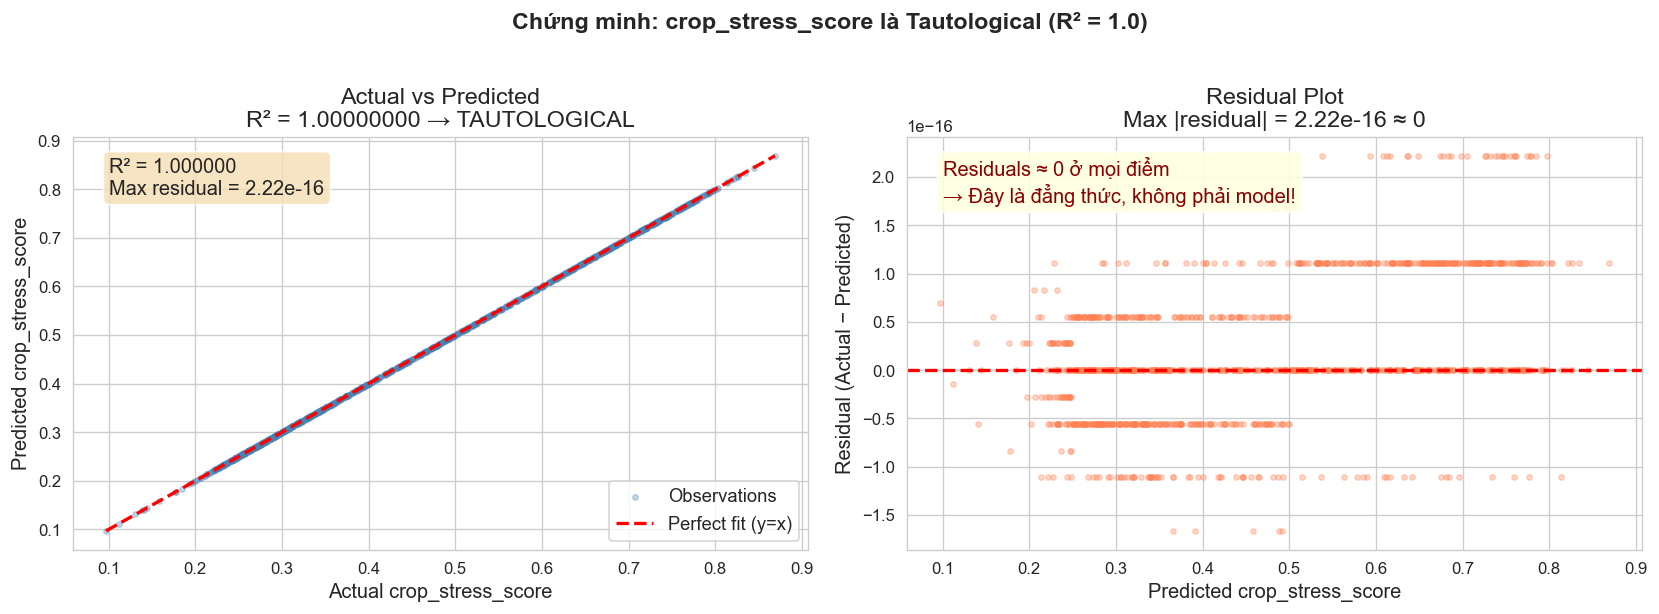

Saved: fig01_tautology_proof.png


In [5]:
# Visualize: actual vs predicted crop_stress_score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
ax = axes[0]
ax.scatter(y_taut, y_pred, alpha=0.3, s=10, color='steelblue', label='Observations')
lims = [min(y_taut.min(), y_pred.min()), max(y_taut.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect fit (y=x)')
ax.set_xlabel('Actual crop_stress_score')
ax.set_ylabel('Predicted crop_stress_score')
ax.set_title(f'Actual vs Predicted\nR² = {r2:.8f} → TAUTOLOGICAL')
ax.legend()
ax.text(0.05, 0.95, f'R² = {r2:.6f}\nMax residual = {max_residual:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Residual plot
ax2 = axes[1]
ax2.scatter(y_pred, residuals, alpha=0.3, s=10, color='coral')
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted crop_stress_score')
ax2.set_ylabel('Residual (Actual − Predicted)')
ax2.set_title(f'Residual Plot\nMax |residual| = {max_residual:.2e} ≈ 0')
ax2.text(0.05, 0.95, 'Residuals ≈ 0 ở mọi điểm\n→ Đây là đẳng thức, không phải model!',
         transform=ax2.transAxes, va='top', color='darkred',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle('Chứng minh: crop_stress_score là Tautological (R² = 1.0)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/fig01_tautology_proof.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig01_tautology_proof.png')

## 1.2 Tạo Target Mới: `is_stress_event`

**Vấn đề với `is_ndvi_anomaly` (target cũ):**
- Định nghĩa: `|ndvi_zscore| > 2` → bắt cả NDVI thấp (stress) VÀ NDVI cao (bloom)
- Kết quả: 66 anomalies = 44 negative + 22 positive
- 22 positive anomalies là **bloom events** (cây phát triển mạnh), KHÔNG phải stress

**Target mới `is_stress_event`:**
- Định nghĩa: `monthly_ndvi_zscore < -2` → chỉ bắt các sự kiện NDVI suy giảm bất thường
- Kết quả: 44 positive samples (true stress events)

In [6]:
# Tính monthly z-score cho NDVI (chuẩn hóa trong từng tháng)
# Điều này loại trừ seasonal effect trước khi tính anomaly

df['date'] = pd.to_datetime(df['date'])

# Monthly stats
monthly_stats = df.groupby('month')['ndvi'].agg(['mean', 'std']).rename(
    columns={'mean': 'ndvi_monthly_mean', 'std': 'ndvi_monthly_std'}
)

df = df.merge(monthly_stats, on='month', how='left')
df['monthly_ndvi_zscore'] = (
    (df['ndvi'] - df['ndvi_monthly_mean']) / df['ndvi_monthly_std']
)

# Target mới: chỉ negative anomalies (stress)
df['is_stress_event'] = (df['monthly_ndvi_zscore'] < -2).astype(int)

# So sánh
n_old = df['is_ndvi_anomaly'].sum()
n_old_neg = (df['ndvi_zscore'] < -2).sum()  # negative anomalies trong target cũ
n_old_pos = (df['ndvi_zscore'] > 2).sum()   # positive anomalies (bloom) trong target cũ
n_new = df['is_stress_event'].sum()

print('=' * 50)
print('  SO SÁNH TARGET CŨ vs MỚI')
print('=' * 50)
print(f'  is_ndvi_anomaly (cũ): {n_old} events')
print(f'    → Stress (NDVI thấp): {n_old_neg}')
print(f'    → Bloom  (NDVI cao) : {n_old_pos}  ← loại bỏ!')
print(f'  is_stress_event (mới): {n_new} events')
print(f'    → Chỉ negative anomalies (stress thật)')
print(f'  Class balance mới: {n_new}/{len(df)} = {n_new/len(df)*100:.1f}%')
print('=' * 50)

  SO SÁNH TARGET CŨ vs MỚI
  is_ndvi_anomaly (cũ): 66 events
    → Stress (NDVI thấp): 44
    → Bloom  (NDVI cao) : 22  ← loại bỏ!
  is_stress_event (mới): 44 events
    → Chỉ negative anomalies (stress thật)
  Class balance mới: 44/1096 = 4.0%


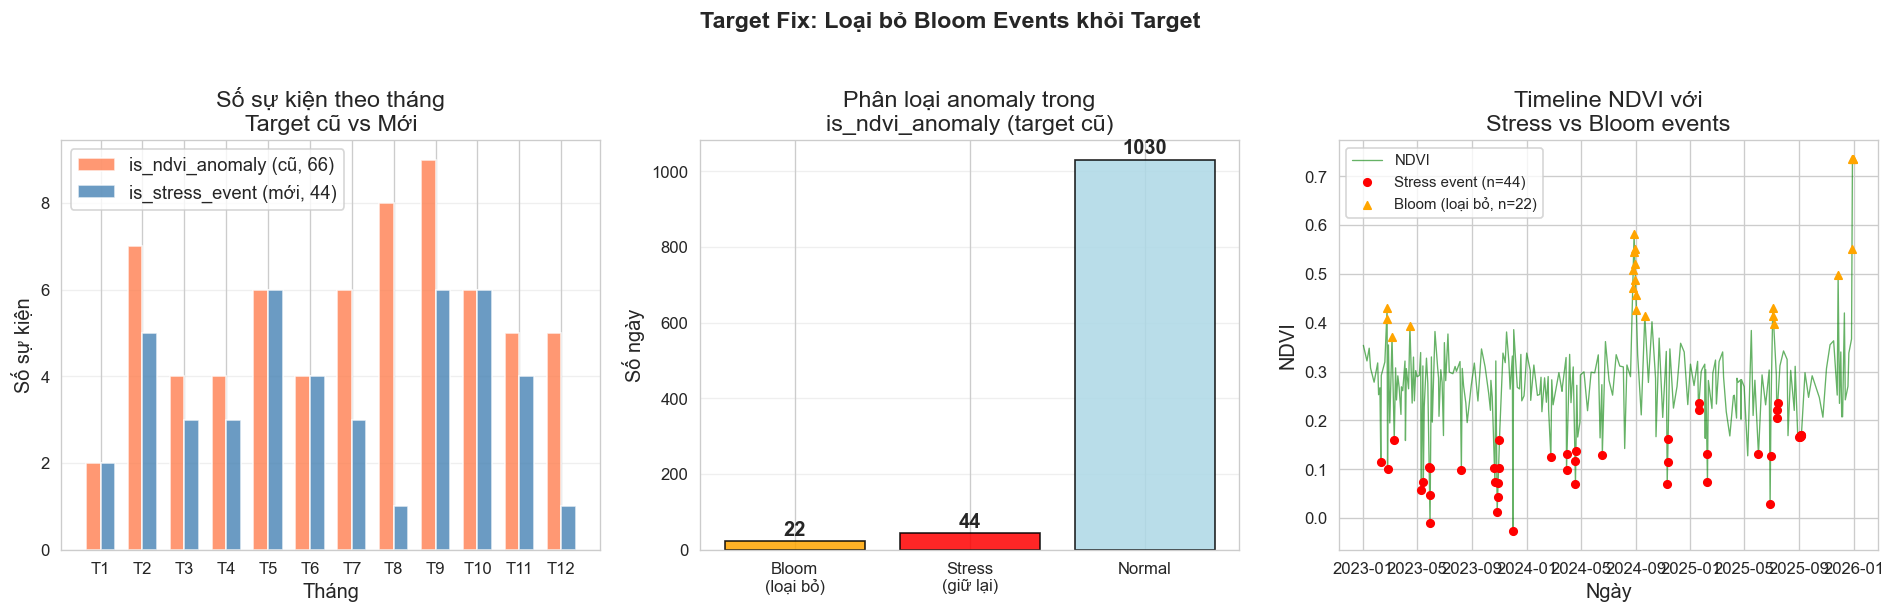

In [7]:
# Visualize: so sánh target cũ vs mới theo tháng
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Bar chart events theo tháng ---
ax = axes[0]
old_monthly = df.groupby('month')['is_ndvi_anomaly'].sum()
new_monthly = df.groupby('month')['is_stress_event'].sum()
x = np.arange(1, 13)
width = 0.35
bars1 = ax.bar(x - width/2, old_monthly, width, label='is_ndvi_anomaly (cũ, 66)', 
               color='coral', alpha=0.8)
bars2 = ax.bar(x + width/2, new_monthly, width, label='is_stress_event (mới, 44)',
               color='steelblue', alpha=0.8)
ax.set_xlabel('Tháng')
ax.set_ylabel('Số sự kiện')
ax.set_title('Số sự kiện theo tháng\nTarget cũ vs Mới')
ax.set_xticks(x)
ax.set_xticklabels([f'T{i}' for i in range(1, 13)])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# --- Plot 2: Phân loại anomaly cũ ---
ax2 = axes[1]
bloom_mask = df['ndvi_zscore'] > 2
stress_mask = df['ndvi_zscore'] < -2
categories = ['Bloom\n(loại bỏ)', 'Stress\n(giữ lại)', 'Normal']
counts = [bloom_mask.sum(), stress_mask.sum(), (~bloom_mask & ~stress_mask).sum()]
colors = ['orange', 'red', 'lightblue']
bars = ax2.bar(categories, counts, color=colors, alpha=0.85, edgecolor='black')
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold')
ax2.set_ylabel('Số ngày')
ax2.set_title('Phân loại anomaly trong\nis_ndvi_anomaly (target cũ)')
ax2.grid(axis='y', alpha=0.3)

# --- Plot 3: Timeline NDVI với stress events ---
ax3 = axes[2]
ax3.plot(df['date'], df['ndvi'], color='green', alpha=0.6, linewidth=0.8, label='NDVI')
stress_dates = df[df['is_stress_event'] == 1]
bloom_dates = df[bloom_mask]
ax3.scatter(stress_dates['date'], stress_dates['ndvi'], color='red', s=20, 
            zorder=5, label=f'Stress event (n={len(stress_dates)})')
ax3.scatter(bloom_dates['date'], bloom_dates['ndvi'], color='orange', s=20,
            zorder=5, label=f'Bloom (loại bỏ, n={len(bloom_dates)})', marker='^')
ax3.set_xlabel('Ngày')
ax3.set_ylabel('NDVI')
ax3.set_title('Timeline NDVI với\nStress vs Bloom events')
ax3.legend(fontsize=9)

plt.suptitle('Target Fix: Loại bỏ Bloom Events khỏi Target', fontsize=14, 
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/fig02_target_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [8]:
# === LOẠI BỎ FEATURES THEO KẾ HOẠCH ===

FEATURES_TO_DROP = [
    'crop_stress_score',    # tautological (R²=1.0)
    'is_ndvi_anomaly',      # target cũ, bị lỗi
    'ndvi_zscore',          # derived from target logic
    'ndvi_diff',            # chứa ndvi(t) → leakage khi deploy
    'ndvi_pct_change',      # chứa ndvi(t) → leakage khi deploy
    'salinity_lag_1',       # r > 0.94 với salinity_psu (multicollinearity)
    'salinity_lag_3',       # r > 0.94 với salinity_psu
    'salinity_lag_7',       # r > 0.94 với salinity_psu
    'precip_7d_mm',         # duplicate của precip_7d_sum
    'rain',                 # duplicate của precipitation
    'precip_lag_1',         # ít informative
    'precip_lag_3',         # ít informative
    'precip_lag_7',         # ít informative
]

# Thêm các cột tạm dùng cho monthly zscore computation
TEMP_COLS = ['ndvi_monthly_mean', 'ndvi_monthly_std', 'monthly_ndvi_zscore']

# Kiểm tra trước khi drop
print('Features sẽ bị loại bỏ:')
for f in FEATURES_TO_DROP:
    exists = f in df.columns
    print(f'  {f:<30}: {"✓ tồn tại" if exists else "✗ không có"}')

# Drop
cols_to_drop = [c for c in FEATURES_TO_DROP + TEMP_COLS if c in df.columns]
df_v2 = df.drop(columns=cols_to_drop)

print(f'\nDataset gốc  : {df.shape[1]} cột')
print(f'Dataset mới  : {df_v2.shape[1]} cột')
print(f'Đã loại bỏ   : {len(cols_to_drop)} cột')
print(f'\nCột giữ lại  : {list(df_v2.columns)}')

Features sẽ bị loại bỏ:
  crop_stress_score             : ✓ tồn tại
  is_ndvi_anomaly               : ✓ tồn tại
  ndvi_zscore                   : ✓ tồn tại
  ndvi_diff                     : ✓ tồn tại
  ndvi_pct_change               : ✓ tồn tại
  salinity_lag_1                : ✓ tồn tại
  salinity_lag_3                : ✓ tồn tại
  salinity_lag_7                : ✓ tồn tại
  precip_7d_mm                  : ✓ tồn tại
  rain                          : ✓ tồn tại
  precip_lag_1                  : ✓ tồn tại
  precip_lag_3                  : ✓ tồn tại
  precip_lag_7                  : ✓ tồn tại

Dataset gốc  : 56 cột
Dataset mới  : 40 cột
Đã loại bỏ   : 16 cột

Cột giữ lại  : ['date', 'ndvi', 'ndvi_source', 'lst', 'ndvi_is_observed', 'lst_is_observed', 'temp_max', 'temp_min', 'temp_mean', 'precipitation', 'et0', 'radiation', 'wind_max', 'soil_moisture_surface', 'soil_moisture_deep', 'soil_temp', 'salinity_psu', 'day_of_year', 'month', 'week', 'season', 'is_dry_season', 'month_sin', 'month_co

In [9]:
# Lưu merged_final_v2.csv
df_v2.to_csv(OUTPUT_PATH, index=False)
print(f'Saved: {OUTPUT_PATH}')
print(f'Shape: {df_v2.shape}')
print(f'Target distribution:')
print(df_v2['is_stress_event'].value_counts())
print(f'\nClass imbalance ratio: {df_v2["is_stress_event"].value_counts()[0]/df_v2["is_stress_event"].value_counts()[1]:.1f}:1')

Saved: ../data/merged_final_v2.csv
Shape: (1096, 40)
Target distribution:
is_stress_event
0    1052
1      44
Name: count, dtype: int64

Class imbalance ratio: 23.9:1


---
# PHẦN 2: Correlation Analysis Toàn Diện

## 2.1 Spearman Correlation Heatmap

**Tại sao dùng Spearman thay vì Pearson?**
- Spearman đo **rank correlation** — bắt được quan hệ đơn điệu kể cả phi tuyến
- Phù hợp hơn với dữ liệu môi trường thường có outliers và phân phối lệch
- Nếu Spearman >> Pearson → quan hệ phi tuyến (monotonic nhưng không linear)

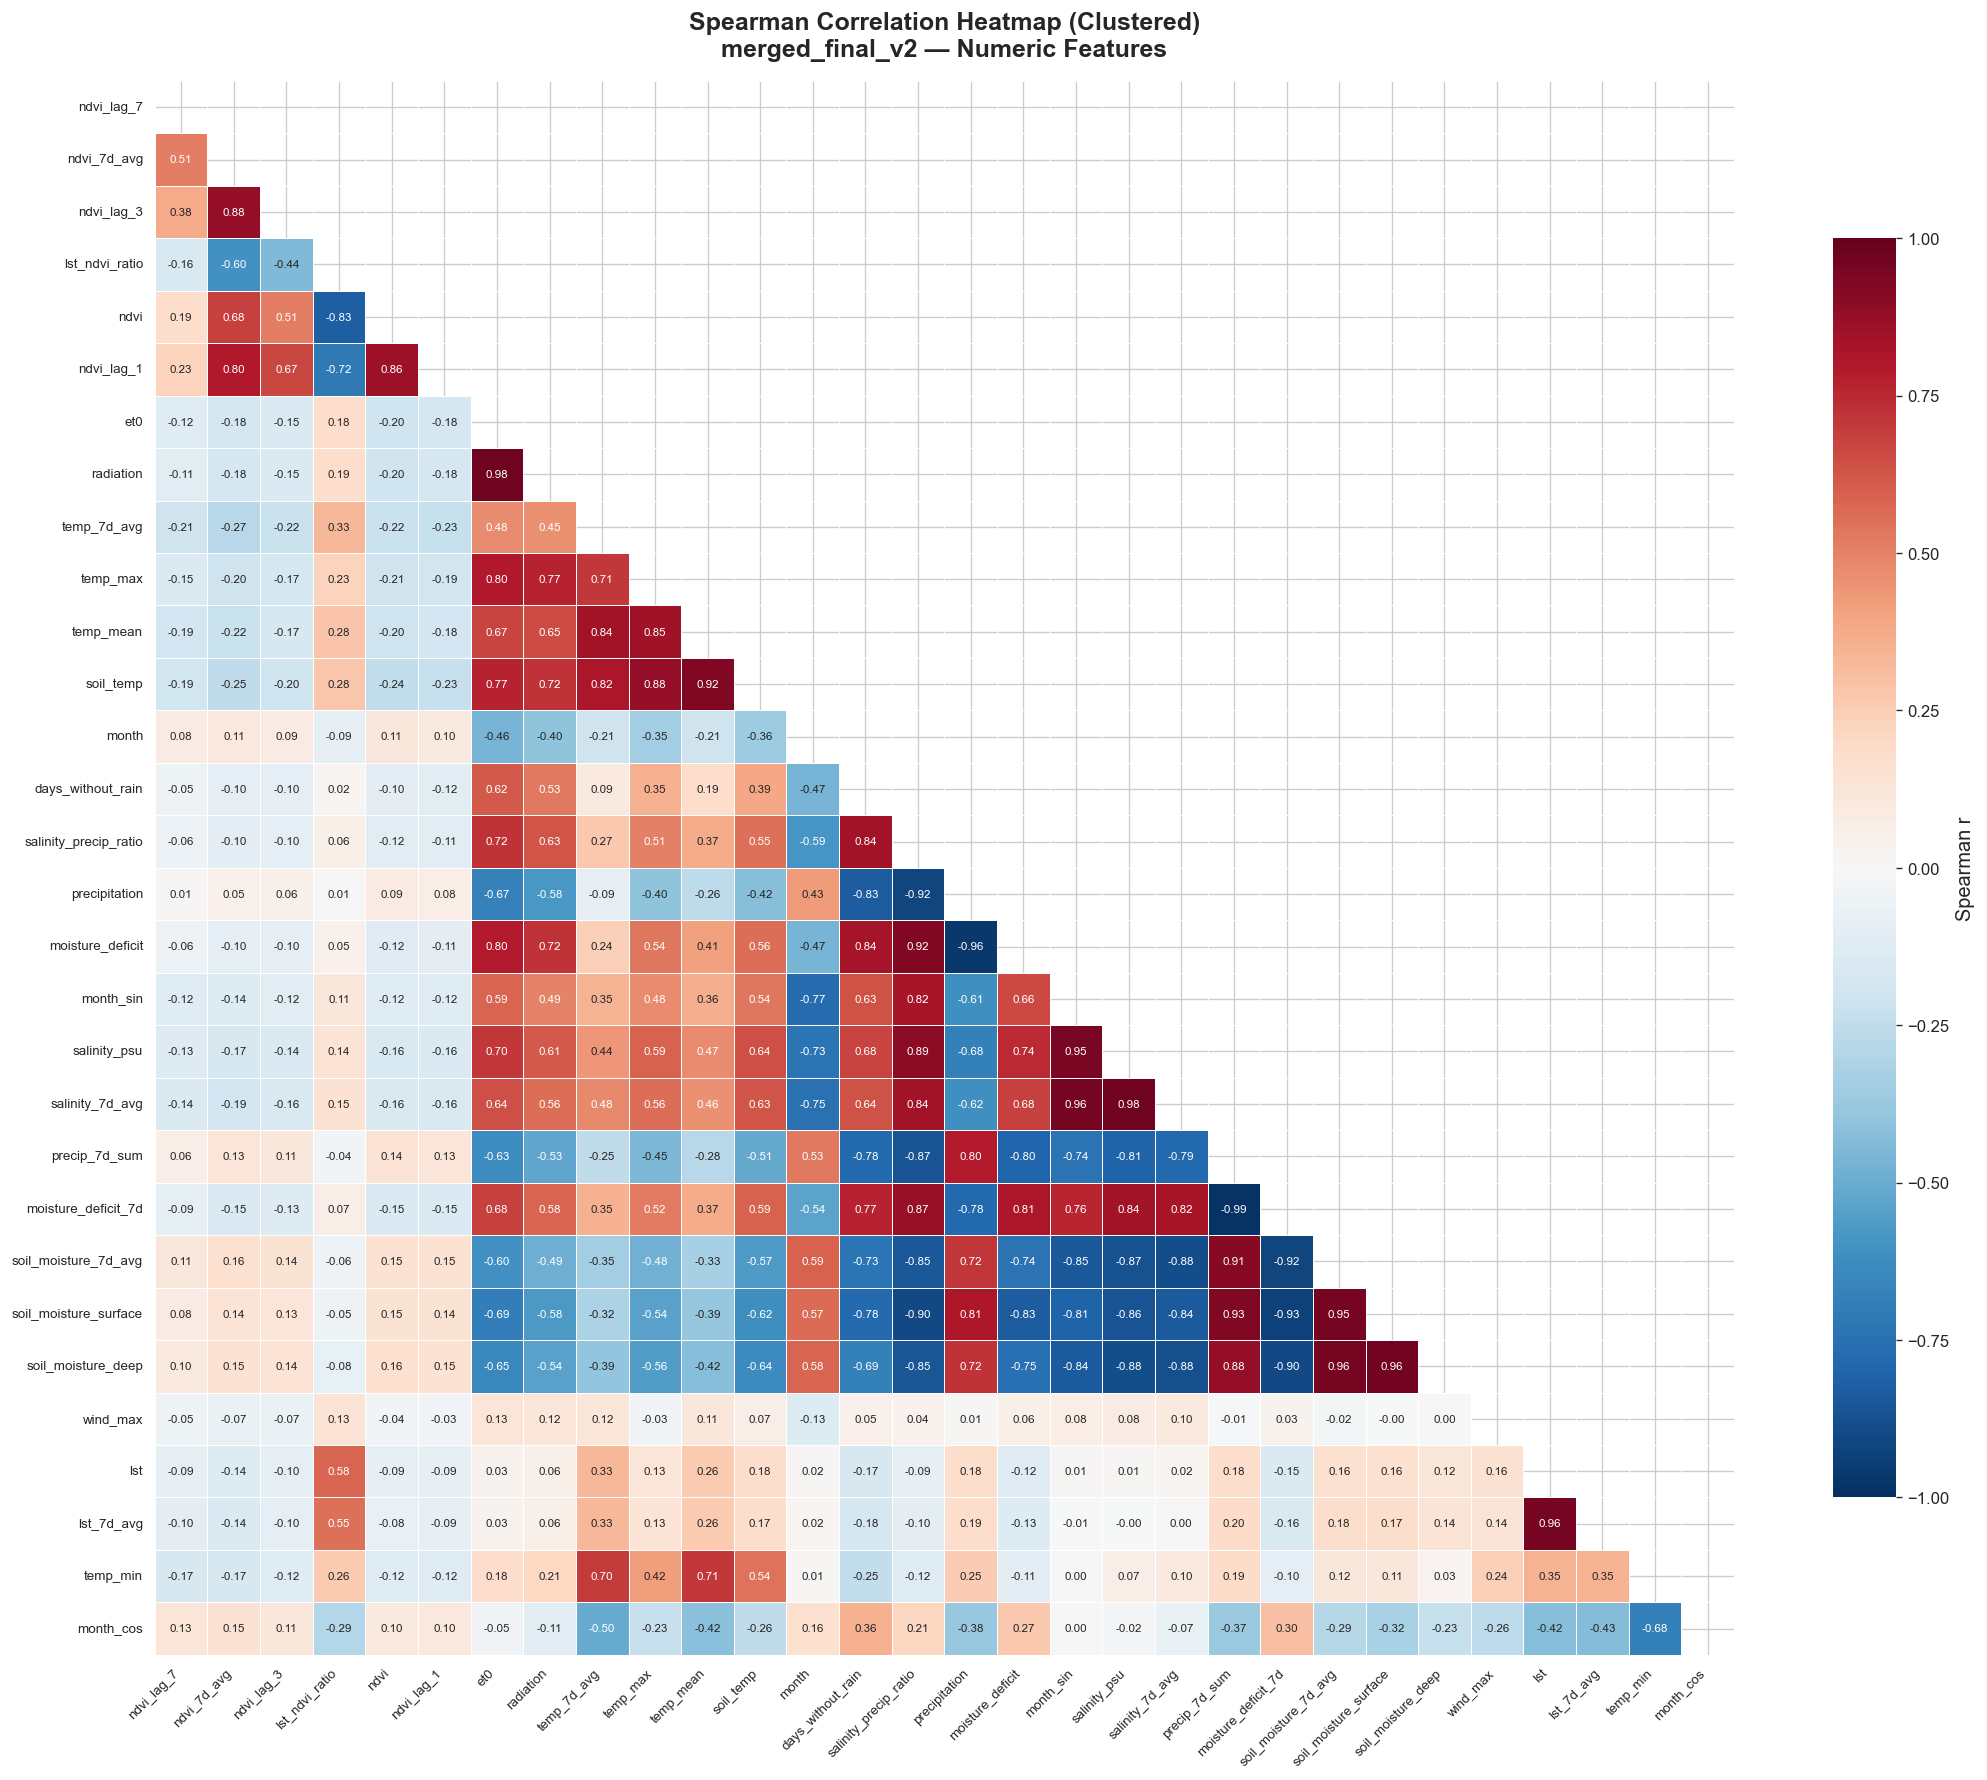

Saved: fig03_spearman_heatmap.png


In [10]:
# Chọn numeric features để compute correlation
numeric_cols = df_v2.select_dtypes(include=[np.number]).columns.tolist()
# Loại bỏ cột không cần thiết cho correlation heatmap
exclude_from_heatmap = ['day_of_year', 'week', 'is_stress_event', 'ndvi_is_observed', 
                         'lst_is_observed', 'is_salinity_spike', 'is_dry_season']
heatmap_cols = [c for c in numeric_cols if c not in exclude_from_heatmap]

# Spearman correlation matrix
spearman_corr = df_v2[heatmap_cols].corr(method='spearman')

# Cluster using linkage
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
dist_matrix = 1 - np.abs(spearman_corr)
np.fill_diagonal(dist_matrix.values, 0)
dist_condensed = squareform(dist_matrix)
linkage = hierarchy.linkage(dist_condensed, method='average')
order = hierarchy.leaves_list(linkage)
ordered_cols = [heatmap_cols[i] for i in order]
spearman_ordered = spearman_corr.loc[ordered_cols, ordered_cols]

# Plot
fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(spearman_ordered, dtype=bool))
sns.heatmap(
    spearman_ordered, mask=mask, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8, 'label': 'Spearman r'}
)
ax.set_title('Spearman Correlation Heatmap (Clustered)\nmerged_final_v2 — Numeric Features',
             fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('../reports/fig03_spearman_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig03_spearman_heatmap.png')

## 2.2 Pearson vs Spearman — Phát Hiện Quan Hệ Phi Tuyến

**Nguyên tắc:** Nếu `|Spearman r| >> |Pearson r|` cho một cặp biến, điều đó chứng tỏ quan hệ giữa hai biến là **monotonic nhưng phi tuyến** (ví dụ: logarithmic, threshold-based, sigmoid).

In [11]:
# So sánh Pearson vs Spearman cho các cặp quan trọng
pairs_to_compare = [
    ('salinity_psu', 'ndvi'),
    ('salinity_psu', 'soil_moisture_surface'),
    ('soil_moisture_surface', 'ndvi'),
    ('precipitation', 'ndvi'),
    ('lst', 'ndvi'),
    ('temp_mean', 'ndvi'),
    ('moisture_deficit', 'ndvi'),
    ('salinity_7d_avg', 'ndvi'),
]

results = []
for x_col, y_col in pairs_to_compare:
    mask = df_v2[[x_col, y_col]].notna().all(axis=1)
    x = df_v2.loc[mask, x_col]
    y = df_v2.loc[mask, y_col]
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)
    diff = abs(spearman_r) - abs(pearson_r)
    results.append({
        'Cặp biến': f'{x_col} → {y_col}',
        'Pearson r': round(pearson_r, 4),
        'Spearman r': round(spearman_r, 4),
        '|Spear| - |Pear|': round(diff, 4),
        'Kết luận': 'PHI TUYẾN' if diff > 0.05 else ('Tuyến tính' if diff < -0.02 else 'Tương đương')
    })

results_df = pd.DataFrame(results)
print('So sánh Pearson vs Spearman Correlation:')
print(results_df.to_string(index=False))

So sánh Pearson vs Spearman Correlation:
                            Cặp biến  Pearson r  Spearman r  |Spear| - |Pear|    Kết luận
                 salinity_psu → ndvi    -0.1494     -0.1599            0.0105 Tương đương
salinity_psu → soil_moisture_surface    -0.8546     -0.8634            0.0088 Tương đương
        soil_moisture_surface → ndvi     0.1130      0.1484            0.0354 Tương đương
                precipitation → ndvi     0.0668      0.0878            0.0209 Tương đương
                          lst → ndvi    -0.1220     -0.0907           -0.0312  Tuyến tính
                    temp_mean → ndvi    -0.2039     -0.2035           -0.0004 Tương đương
             moisture_deficit → ndvi    -0.0820     -0.1195            0.0374 Tương đương
              salinity_7d_avg → ndvi    -0.1538     -0.1625            0.0088 Tương đương


## 2.3 Phân Tích Phi Tuyến: Salinity → NDVI

Dữ liệu salinity tại ĐBSCL có đặc điểm **threshold-based**: cây trồng có thể chịu được độ mặn nhẹ đến vừa (< 8 PSU), nhưng khi vượt ngưỡng 15 PSU, cây bắt đầu bị tổn thương nghiêm trọng và NDVI suy giảm rõ rệt.

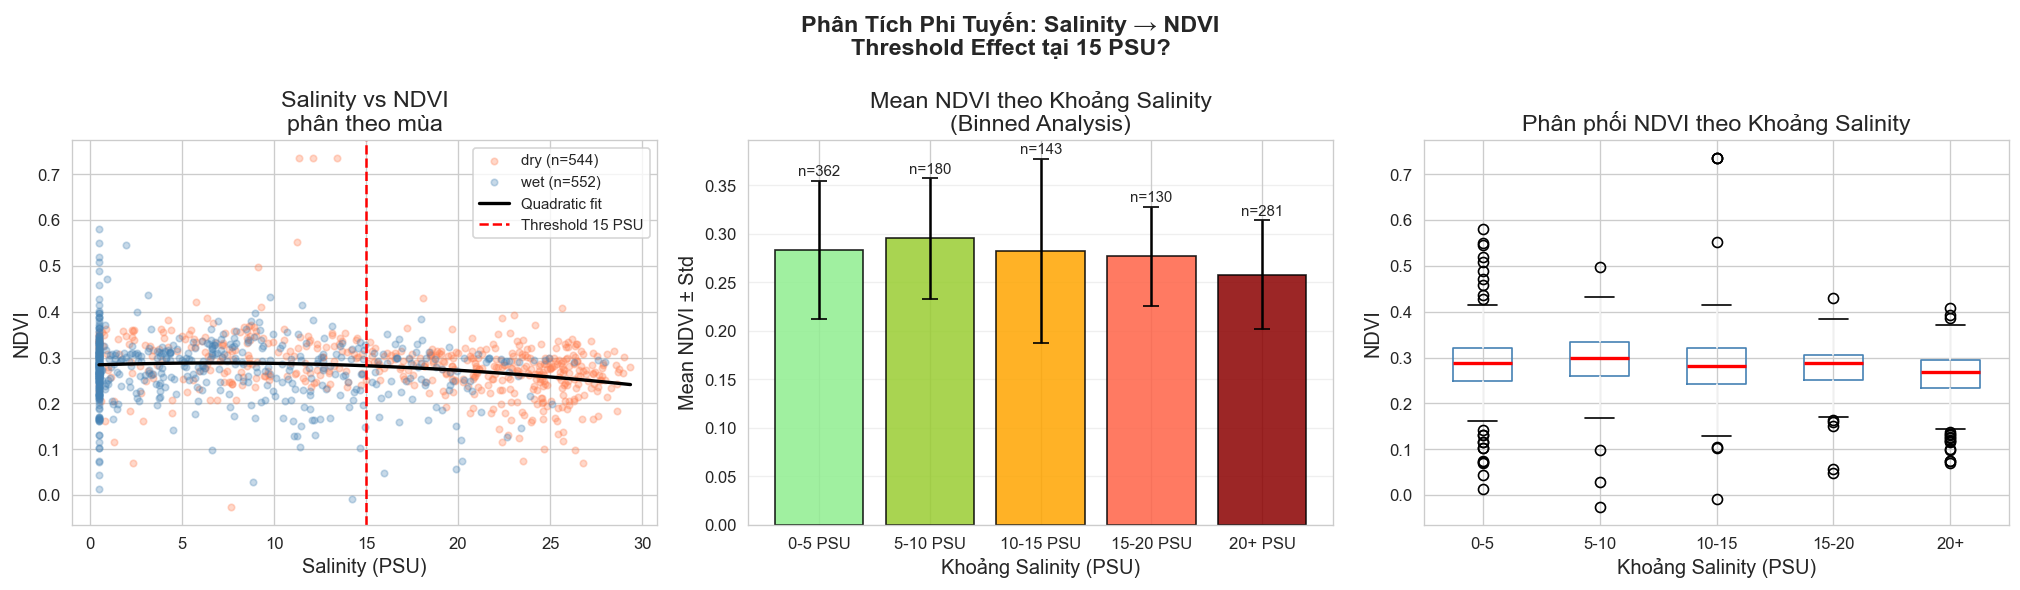


Mean NDVI theo khoảng salinity:
           mean     std  count
sal_bin                       
0-5      0.2835  0.0715    362
5-10     0.2952  0.0622    180
10-15    0.2826  0.0950    143
15-20    0.2767  0.0512    130
20+      0.2579  0.0559    281

NDVI giảm từ 0.284 (0-5 PSU) xuống 0.277 (15-20 PSU)
→ Mức giảm: 2.4%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Plot 1: Scatter salinity vs NDVI, color by season ---
ax = axes[0]
season_colors = {'dry': 'coral', 'wet': 'steelblue'}
for season, grp in df_v2.groupby('season'):
    ax.scatter(grp['salinity_psu'], grp['ndvi'], 
               c=season_colors.get(season, 'gray'), alpha=0.3, s=15,
               label=f'{season} (n={len(grp)})')
# Fit quadratic trend
sal_valid = df_v2[['salinity_psu', 'ndvi']].dropna()
z = np.polyfit(sal_valid['salinity_psu'], sal_valid['ndvi'], 2)
p = np.poly1d(z)
x_range = np.linspace(sal_valid['salinity_psu'].min(), sal_valid['salinity_psu'].max(), 100)
ax.plot(x_range, p(x_range), 'k-', linewidth=2, label='Quadratic fit')
ax.axvline(x=15, color='red', linestyle='--', linewidth=1.5, label='Threshold 15 PSU')
ax.set_xlabel('Salinity (PSU)')
ax.set_ylabel('NDVI')
ax.set_title('Salinity vs NDVI\nphân theo mùa')
ax.legend(fontsize=9)

# --- Plot 2: Binned analysis ---
ax2 = axes[1]
bins = [0, 5, 10, 15, 20, df_v2['salinity_psu'].max() + 0.1]
bin_labels = ['0-5', '5-10', '10-15', '15-20', '20+']
df_v2['sal_bin'] = pd.cut(df_v2['salinity_psu'], bins=bins, labels=bin_labels)
bin_stats = df_v2.groupby('sal_bin', observed=True)['ndvi'].agg(['mean', 'std', 'count'])
x_pos = range(len(bin_stats))
bars = ax2.bar(x_pos, bin_stats['mean'], yerr=bin_stats['std'], 
                capsize=5, color=['lightgreen', 'yellowgreen', 'orange', 'tomato', 'darkred'],
                alpha=0.85, edgecolor='black')
for i, (idx, row) in enumerate(bin_stats.iterrows()):
    ax2.text(i, row['mean'] + row['std'] + 0.005, f'n={int(row["count"])}',
             ha='center', fontsize=9)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'{l} PSU' for l in bin_labels])
ax2.set_xlabel('Khoảng Salinity (PSU)')
ax2.set_ylabel('Mean NDVI ± Std')
ax2.set_title('Mean NDVI theo Khoảng Salinity\n(Binned Analysis)')
ax2.grid(axis='y', alpha=0.3)

# --- Plot 3: Box plot ---
ax3 = axes[2]
df_v2.boxplot(column='ndvi', by='sal_bin', ax=ax3, 
              boxprops=dict(color='steelblue'),
              medianprops=dict(color='red', linewidth=2))
ax3.set_xlabel('Khoảng Salinity (PSU)')
ax3.set_ylabel('NDVI')
ax3.set_title('Phân phối NDVI theo\nKhoảng Salinity')
plt.sca(ax3)
plt.title('Phân phối NDVI theo Khoảng Salinity')

plt.suptitle('Phân Tích Phi Tuyến: Salinity → NDVI\nThreshold Effect tại 15 PSU?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig04_nonlinear_salinity_ndvi.png', bbox_inches='tight', dpi=150)
plt.show()

# In kết luận
print('\nMean NDVI theo khoảng salinity:')
print(bin_stats[['mean', 'std', 'count']].round(4))
ndvi_high = bin_stats.loc['15-20', 'mean'] if '15-20' in bin_stats.index else None
ndvi_low = bin_stats.loc['0-5', 'mean'] if '0-5' in bin_stats.index else None
if ndvi_high and ndvi_low:
    print(f'\nNDVI giảm từ {ndvi_low:.3f} (0-5 PSU) xuống {ndvi_high:.3f} (15-20 PSU)')
    print(f'→ Mức giảm: {(ndvi_low - ndvi_high)/ndvi_low * 100:.1f}%')

## 2.4 Multicollinearity Detection — VIF Analysis

**VIF (Variance Inflation Factor)** đo mức độ multicollinearity:
- VIF = 1: Không có multicollinearity
- VIF 1-5: Tương đối OK
- VIF 5-10: Cần xem xét
- **VIF > 10: Nghiêm trọng — nên loại bỏ**

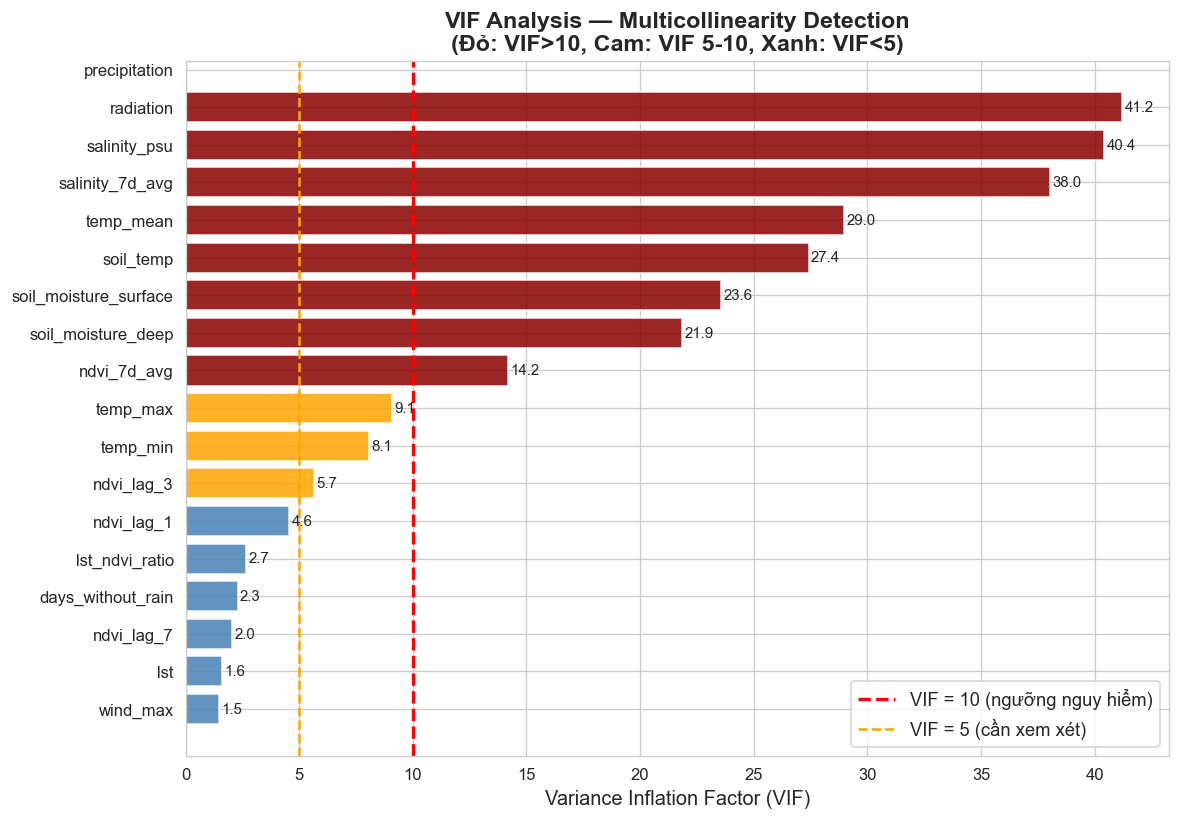


Features có VIF > 10 (multicollinearity nghiêm trọng):
              Feature   VIF
                  et0   inf
     moisture_deficit   inf
        precipitation   inf
            radiation 41.20
         salinity_psu 40.41
      salinity_7d_avg 38.05
            temp_mean 28.99
            soil_temp 27.42
soil_moisture_surface 23.56
   soil_moisture_deep 21.85
          ndvi_7d_avg 14.19


In [13]:
# Chọn top features cho VIF analysis
vif_features = [
    'salinity_psu', 'salinity_7d_avg', 'temp_mean', 'temp_max', 'temp_min',
    'precipitation', 'et0', 'radiation', 'wind_max',
    'soil_moisture_surface', 'soil_moisture_deep', 'soil_temp',
    'lst', 'ndvi_lag_1', 'ndvi_lag_3', 'ndvi_lag_7', 'ndvi_7d_avg',
    'moisture_deficit', 'days_without_rain', 'lst_ndvi_ratio'
]
vif_features = [f for f in vif_features if f in df_v2.columns]

X_vif = df_v2[vif_features].dropna()
X_vif_scaled = StandardScaler().fit_transform(X_vif)
X_vif_df = pd.DataFrame(X_vif_scaled, columns=vif_features)

vif_data = []
for i, col in enumerate(vif_features):
    vif_val = variance_inflation_factor(X_vif_df.values, i)
    vif_data.append({'Feature': col, 'VIF': round(vif_val, 2)})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['darkred' if v > 10 else ('orange' if v > 5 else 'steelblue') for v in vif_df['VIF']]
bars = ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors, alpha=0.85)
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, label='VIF = 10 (ngưỡng nguy hiểm)')
ax.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='VIF = 5 (cần xem xét)')
for bar, val in zip(bars, vif_df['VIF']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_xlabel('Variance Inflation Factor (VIF)')
ax.set_title('VIF Analysis — Multicollinearity Detection\n(Đỏ: VIF>10, Cam: VIF 5-10, Xanh: VIF<5)',
             fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/fig05_vif_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nFeatures có VIF > 10 (multicollinearity nghiêm trọng):')
high_vif = vif_df[vif_df['VIF'] > 10]
if len(high_vif) > 0:
    print(high_vif.to_string(index=False))
else:
    print('  → Không có feature nào có VIF > 10 sau khi đã loại bỏ salinity_lag')

## 2.5 Cross-Correlation Function (CCF): Raw vs Differenced

**Mục tiêu:** Tìm lag tối ưu cho salinity → NDVI và precipitation → NDVI.

**Lần 1:** Tính CCF trên raw data (có thể bị nhiễu do non-stationarity)  
**Lần 2:** Tính CCF sau first-differencing (loại bỏ trend, stationary hơn)  

> Nếu CCF raw gần 0 nhưng CCF differenced có peak rõ → vấn đề non-stationarity masking correlation.

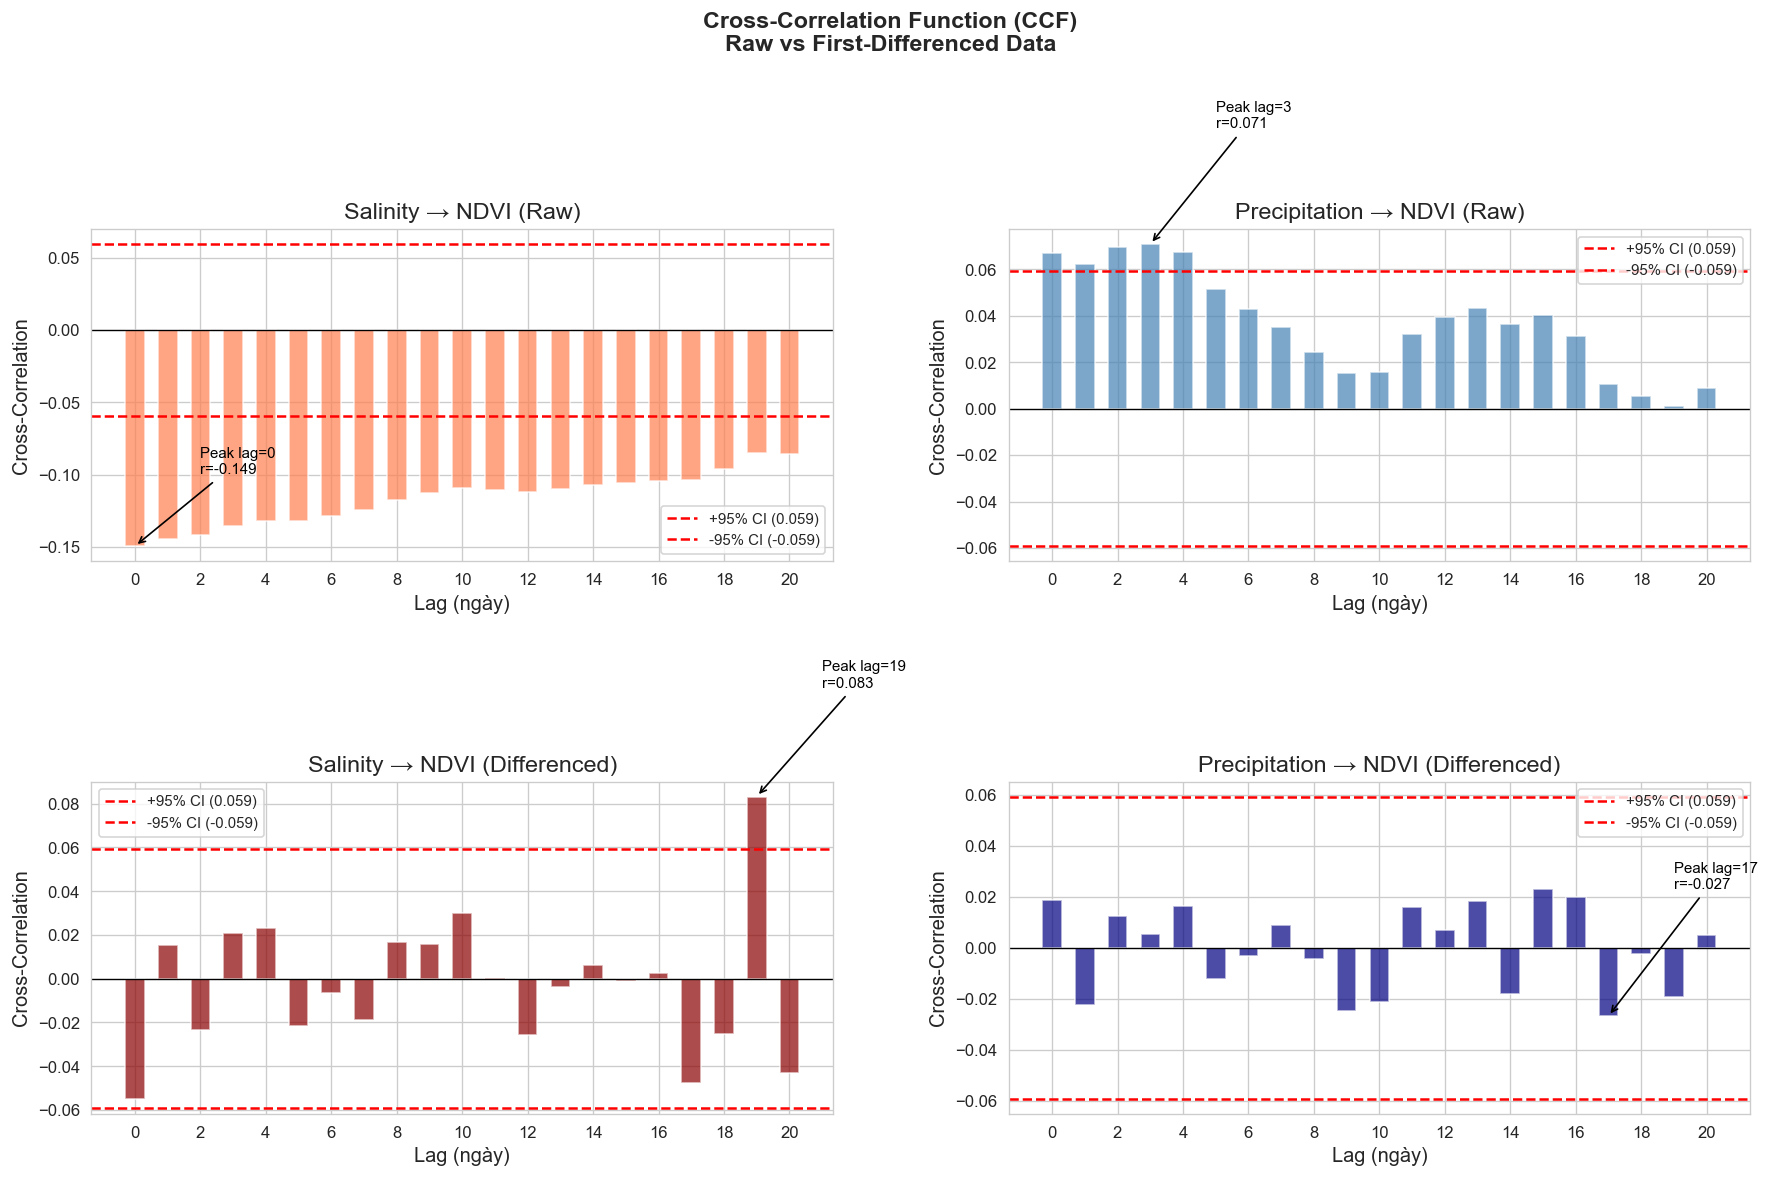


95% CI: ±0.0592
Salinity→NDVI (raw)    peak: lag=0, r=-0.1494
Precip→NDVI (raw)      peak: lag=3, r=0.0708
Salinity→NDVI (diff)   peak: lag=19, r=0.0833
Precip→NDVI (diff)     peak: lag=17, r=-0.0269


In [14]:
from statsmodels.tsa.stattools import ccf as compute_ccf

max_lag = 21

# Chuẩn bị data
df_ts = df_v2[['date', 'salinity_psu', 'ndvi', 'precipitation']].dropna().set_index('date')

sal = df_ts['salinity_psu'].values
ndvi_ = df_ts['ndvi'].values
precip = df_ts['precipitation'].values

# First differences
sal_diff = np.diff(sal)
ndvi_diff_ = np.diff(ndvi_)
precip_diff = np.diff(precip)

def get_ccf_values(x, y, max_lag):
    """Tính CCF từ lag 0 đến max_lag (hoặc ngắn hơn nếu series không đủ dài)."""
    ccf_vals = compute_ccf(x, y, nlags=max_lag, alpha=None)
    return ccf_vals[: max_lag + 1]

# Raw CCF
ccf_sal_ndvi_raw = get_ccf_values(sal, ndvi_, max_lag)
ccf_prec_ndvi_raw = get_ccf_values(precip, ndvi_, max_lag)

# Differenced CCF
ccf_sal_ndvi_diff = get_ccf_values(sal_diff, ndvi_diff_, max_lag)
ccf_prec_ndvi_diff = get_ccf_values(precip_diff, ndvi_diff_, max_lag)

# Confidence interval
n = len(sal)
ci = 1.96 / np.sqrt(n)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_configs = [
    (ccf_sal_ndvi_raw,  'Salinity → NDVI (Raw)',         'coral',     axes[0, 0]),
    (ccf_prec_ndvi_raw, 'Precipitation → NDVI (Raw)',    'steelblue', axes[0, 1]),
    (ccf_sal_ndvi_diff, 'Salinity → NDVI (Differenced)', 'darkred',   axes[1, 0]),
    (ccf_prec_ndvi_diff,'Precipitation → NDVI (Differenced)', 'navy', axes[1, 1]),
]

for ccf_vals, title, color, ax in plot_configs:
    lags_local = np.arange(len(ccf_vals))
    ax.bar(lags_local, ccf_vals, color=color, alpha=0.7, width=0.6)
    ax.axhline(ci,  color='red', linestyle='--', linewidth=1.5, label=f'+95% CI ({ci:.3f})')
    ax.axhline(-ci, color='red', linestyle='--', linewidth=1.5, label=f'-95% CI ({-ci:.3f})')
    ax.axhline(0,   color='black', linewidth=0.8)
    ax.set_xlabel('Lag (ngày)')
    ax.set_ylabel('Cross-Correlation')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xticks(lags_local[::2])
    
    # Tìm lag có |CCF| max
    peak_lag = np.argmax(np.abs(ccf_vals))
    ax.annotate(f'Peak lag={peak_lag}\nr={ccf_vals[peak_lag]:.3f}',
                xy=(peak_lag, ccf_vals[peak_lag]),
                xytext=(peak_lag + 2, ccf_vals[peak_lag] + 0.05),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9, color='black')

plt.suptitle('Cross-Correlation Function (CCF)\nRaw vs First-Differenced Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig06_ccf_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n95% CI: ±{ci:.4f}')
print(f'Salinity→NDVI (raw)    peak: lag={np.argmax(np.abs(ccf_sal_ndvi_raw))}, r={ccf_sal_ndvi_raw[np.argmax(np.abs(ccf_sal_ndvi_raw))]:.4f}')
print(f'Precip→NDVI (raw)      peak: lag={np.argmax(np.abs(ccf_prec_ndvi_raw))}, r={ccf_prec_ndvi_raw[np.argmax(np.abs(ccf_prec_ndvi_raw))]:.4f}')
print(f'Salinity→NDVI (diff)   peak: lag={np.argmax(np.abs(ccf_sal_ndvi_diff))}, r={ccf_sal_ndvi_diff[np.argmax(np.abs(ccf_sal_ndvi_diff))]:.4f}')
print(f'Precip→NDVI (diff)     peak: lag={np.argmax(np.abs(ccf_prec_ndvi_diff))}, r={ccf_prec_ndvi_diff[np.argmax(np.abs(ccf_prec_ndvi_diff))]:.4f}')

---
# PHẦN 3: Time Series EDA Nâng Cao

## 3.1 Stationarity Test: ADF + KPSS

**Ý nghĩa:**
- **ADF (Augmented Dickey-Fuller):** H0 = non-stationary. p < 0.05 → bác bỏ H0 → **stationary**
- **KPSS:** H0 = stationary. p < 0.05 → bác bỏ H0 → **non-stationary**
- Kết hợp 2 test để kết luận chắc chắn hơn

In [15]:
def run_stationarity_tests(series, name):
    """Chạy ADF + KPSS test và trả về kết quả dưới dạng dict"""
    series_clean = series.dropna()
    
    # ADF test
    adf_result = adfuller(series_clean, autolag='AIC')
    adf_stat, adf_p = adf_result[0], adf_result[1]
    
    # KPSS test
    kpss_result = kpss(series_clean, regression='ct', nlags='auto')
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
    
    # Kết luận
    adf_stationary = adf_p < 0.05
    kpss_stationary = kpss_p >= 0.05
    
    if adf_stationary and kpss_stationary:
        conclusion = 'STATIONARY'
    elif not adf_stationary and not kpss_stationary:
        conclusion = 'NON-STATIONARY'
    elif adf_stationary and not kpss_stationary:
        conclusion = 'Stationary (trend)'  # difference stationary
    else:
        conclusion = 'Non-stat (long memory)'
    
    return {
        'Biến': name,
        'ADF stat': round(adf_stat, 4),
        'ADF p-value': round(adf_p, 4),
        'KPSS stat': round(kpss_stat, 4),
        'KPSS p-value': round(kpss_p, 4),
        'Kết luận': conclusion
    }

variables_to_test = [
    ('ndvi', 'NDVI'),
    ('salinity_psu', 'Salinity (PSU)'),
    ('temp_mean', 'Nhiệt độ TB (°C)'),
    ('precipitation', 'Lượng mưa (mm)'),
    ('soil_moisture_surface', 'Độ ẩm đất bề mặt'),
]

stationarity_results = []
for col, name in variables_to_test:
    if col in df_v2.columns:
        result = run_stationarity_tests(df_v2[col], name)
        stationarity_results.append(result)

stat_df = pd.DataFrame(stationarity_results)
print('=' * 80)
print('KẾT QUẢ STATIONARITY TEST (ADF + KPSS)')
print('=' * 80)
print(stat_df.to_string(index=False))
print('\nGhi chú:')
print('  ADF: p < 0.05 → stationary | KPSS: p > 0.05 → stationary')
print('  NON-STATIONARY → cần differencing trước khi dùng Granger causality')

KẾT QUẢ STATIONARITY TEST (ADF + KPSS)
            Biến  ADF stat  ADF p-value  KPSS stat  KPSS p-value           Kết luận
            NDVI   -5.1863       0.0000     0.0939        0.1000         STATIONARY
  Salinity (PSU)   -1.5950       0.4861     0.1857        0.0213     NON-STATIONARY
Nhiệt độ TB (°C)   -3.9121       0.0019     0.1966        0.0173 Stationary (trend)
  Lượng mưa (mm)   -3.4262       0.0101     0.1516        0.0453 Stationary (trend)
Độ ẩm đất bề mặt   -2.3964       0.1427     0.1862        0.0212     NON-STATIONARY

Ghi chú:
  ADF: p < 0.05 → stationary | KPSS: p > 0.05 → stationary
  NON-STATIONARY → cần differencing trước khi dùng Granger causality


C:\Users\ADMINN\AppData\Local\Temp\ipykernel_8256\2098142261.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series_clean, regression='ct', nlags='auto')


## 3.2 ACF/PACF Analysis — Justify Lag Selection

ACF/PACF giúp xác định lag nào của NDVI và salinity thực sự mang thông tin:
- **ACF:** Cho thấy tương quan giữa series với version trễ của chính nó
- **PACF:** Loại trừ ảnh hưởng của các lag trung gian — cho thấy lag "thực sự" quan trọng
- **Kết luận:** Lag 1, 3, 7 có ý nghĩa thống kê không?

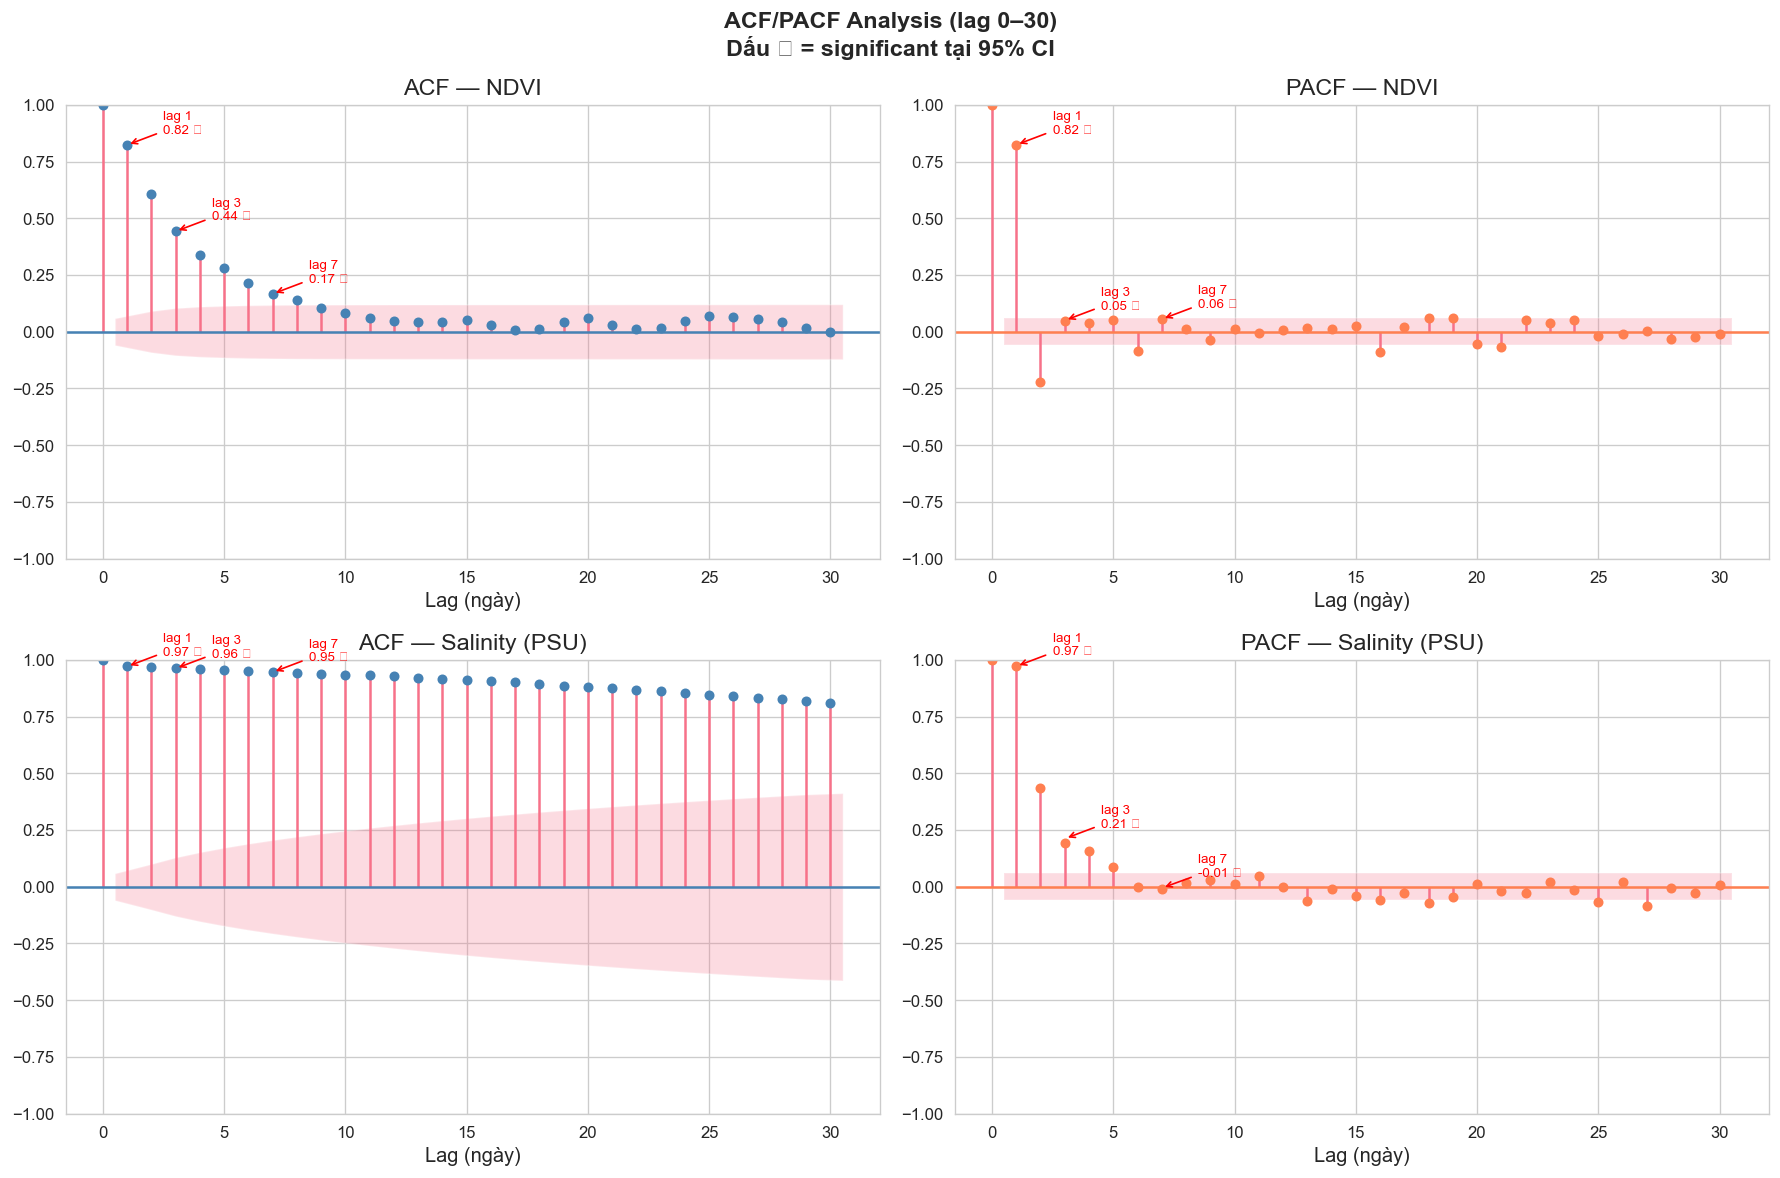


Kết luận ACF cho NDVI:
  Lag  1: r=0.8229 → SIGNIFICANT
  Lag  3: r=0.4421 → SIGNIFICANT
  Lag  7: r=0.1665 → SIGNIFICANT
  Lag 14: r=0.0438 → not significant
  Lag 21: r=0.0308 → not significant
  Lag 30: r=-0.0031 → not significant


In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

max_lag_acf = 30

vars_to_plot = [
    ('ndvi', 'NDVI'),
    ('salinity_psu', 'Salinity (PSU)'),
]

for i, (col, label) in enumerate(vars_to_plot):
    series = df_v2[col].dropna()
    ci_val = 1.96 / np.sqrt(len(series))
    
    # ACF
    ax_acf = axes[i][0]
    plot_acf(series, lags=max_lag_acf, ax=ax_acf, alpha=0.05, 
             title=f'ACF — {label}', color='steelblue')
    # Annotate lag 1, 3, 7
    acf_vals = acf(series, nlags=max_lag_acf)
    for lag in [1, 3, 7]:
        val = acf_vals[lag]
        sig = '✓' if abs(val) > ci_val else '✗'
        ax_acf.annotate(f'lag {lag}\n{val:.2f} {sig}',
                        xy=(lag, val), xytext=(lag + 1.5, val + 0.05),
                        arrowprops=dict(arrowstyle='->', color='red'),
                        fontsize=8, color='red')
    ax_acf.set_xlabel('Lag (ngày)')
    
    # PACF
    ax_pacf = axes[i][1]
    plot_pacf(series, lags=max_lag_acf, ax=ax_pacf, alpha=0.05,
              title=f'PACF — {label}', color='coral')
    pacf_vals = pacf(series, nlags=max_lag_acf)
    for lag in [1, 3, 7]:
        val = pacf_vals[lag]
        sig = '✓' if abs(val) > ci_val else '✗'
        ax_pacf.annotate(f'lag {lag}\n{val:.2f} {sig}',
                         xy=(lag, val), xytext=(lag + 1.5, val + 0.05),
                         arrowprops=dict(arrowstyle='->', color='red'),
                         fontsize=8, color='red')
    ax_pacf.set_xlabel('Lag (ngày)')

plt.suptitle(f'ACF/PACF Analysis (lag 0–{max_lag_acf})\nDấu ✓ = significant tại 95% CI',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig07_acf_pacf.png', bbox_inches='tight', dpi=150)
plt.show()

# Kết luận
ndvi_acf = acf(df_v2['ndvi'].dropna(), nlags=max_lag_acf)
ndvi_ci = 1.96 / np.sqrt(df_v2['ndvi'].notna().sum())
print('\nKết luận ACF cho NDVI:')
for lag in [1, 3, 7, 14, 21, 30]:
    val = ndvi_acf[lag]
    sig = 'SIGNIFICANT' if abs(val) > ndvi_ci else 'not significant'
    print(f'  Lag {lag:2d}: r={val:.4f} → {sig}')

## 3.3 STL Decomposition

**STL (Seasonal-Trend decomposition using LOESS)** tách chuỗi thời gian thành 3 thành phần:
- **Trend:** Xu hướng dài hạn
- **Seasonal:** Biến động theo mùa (period=365 ngày)
- **Residual:** Nhiễu ngẫu nhiên — đây là phần quan trọng nhất để phát hiện anomaly

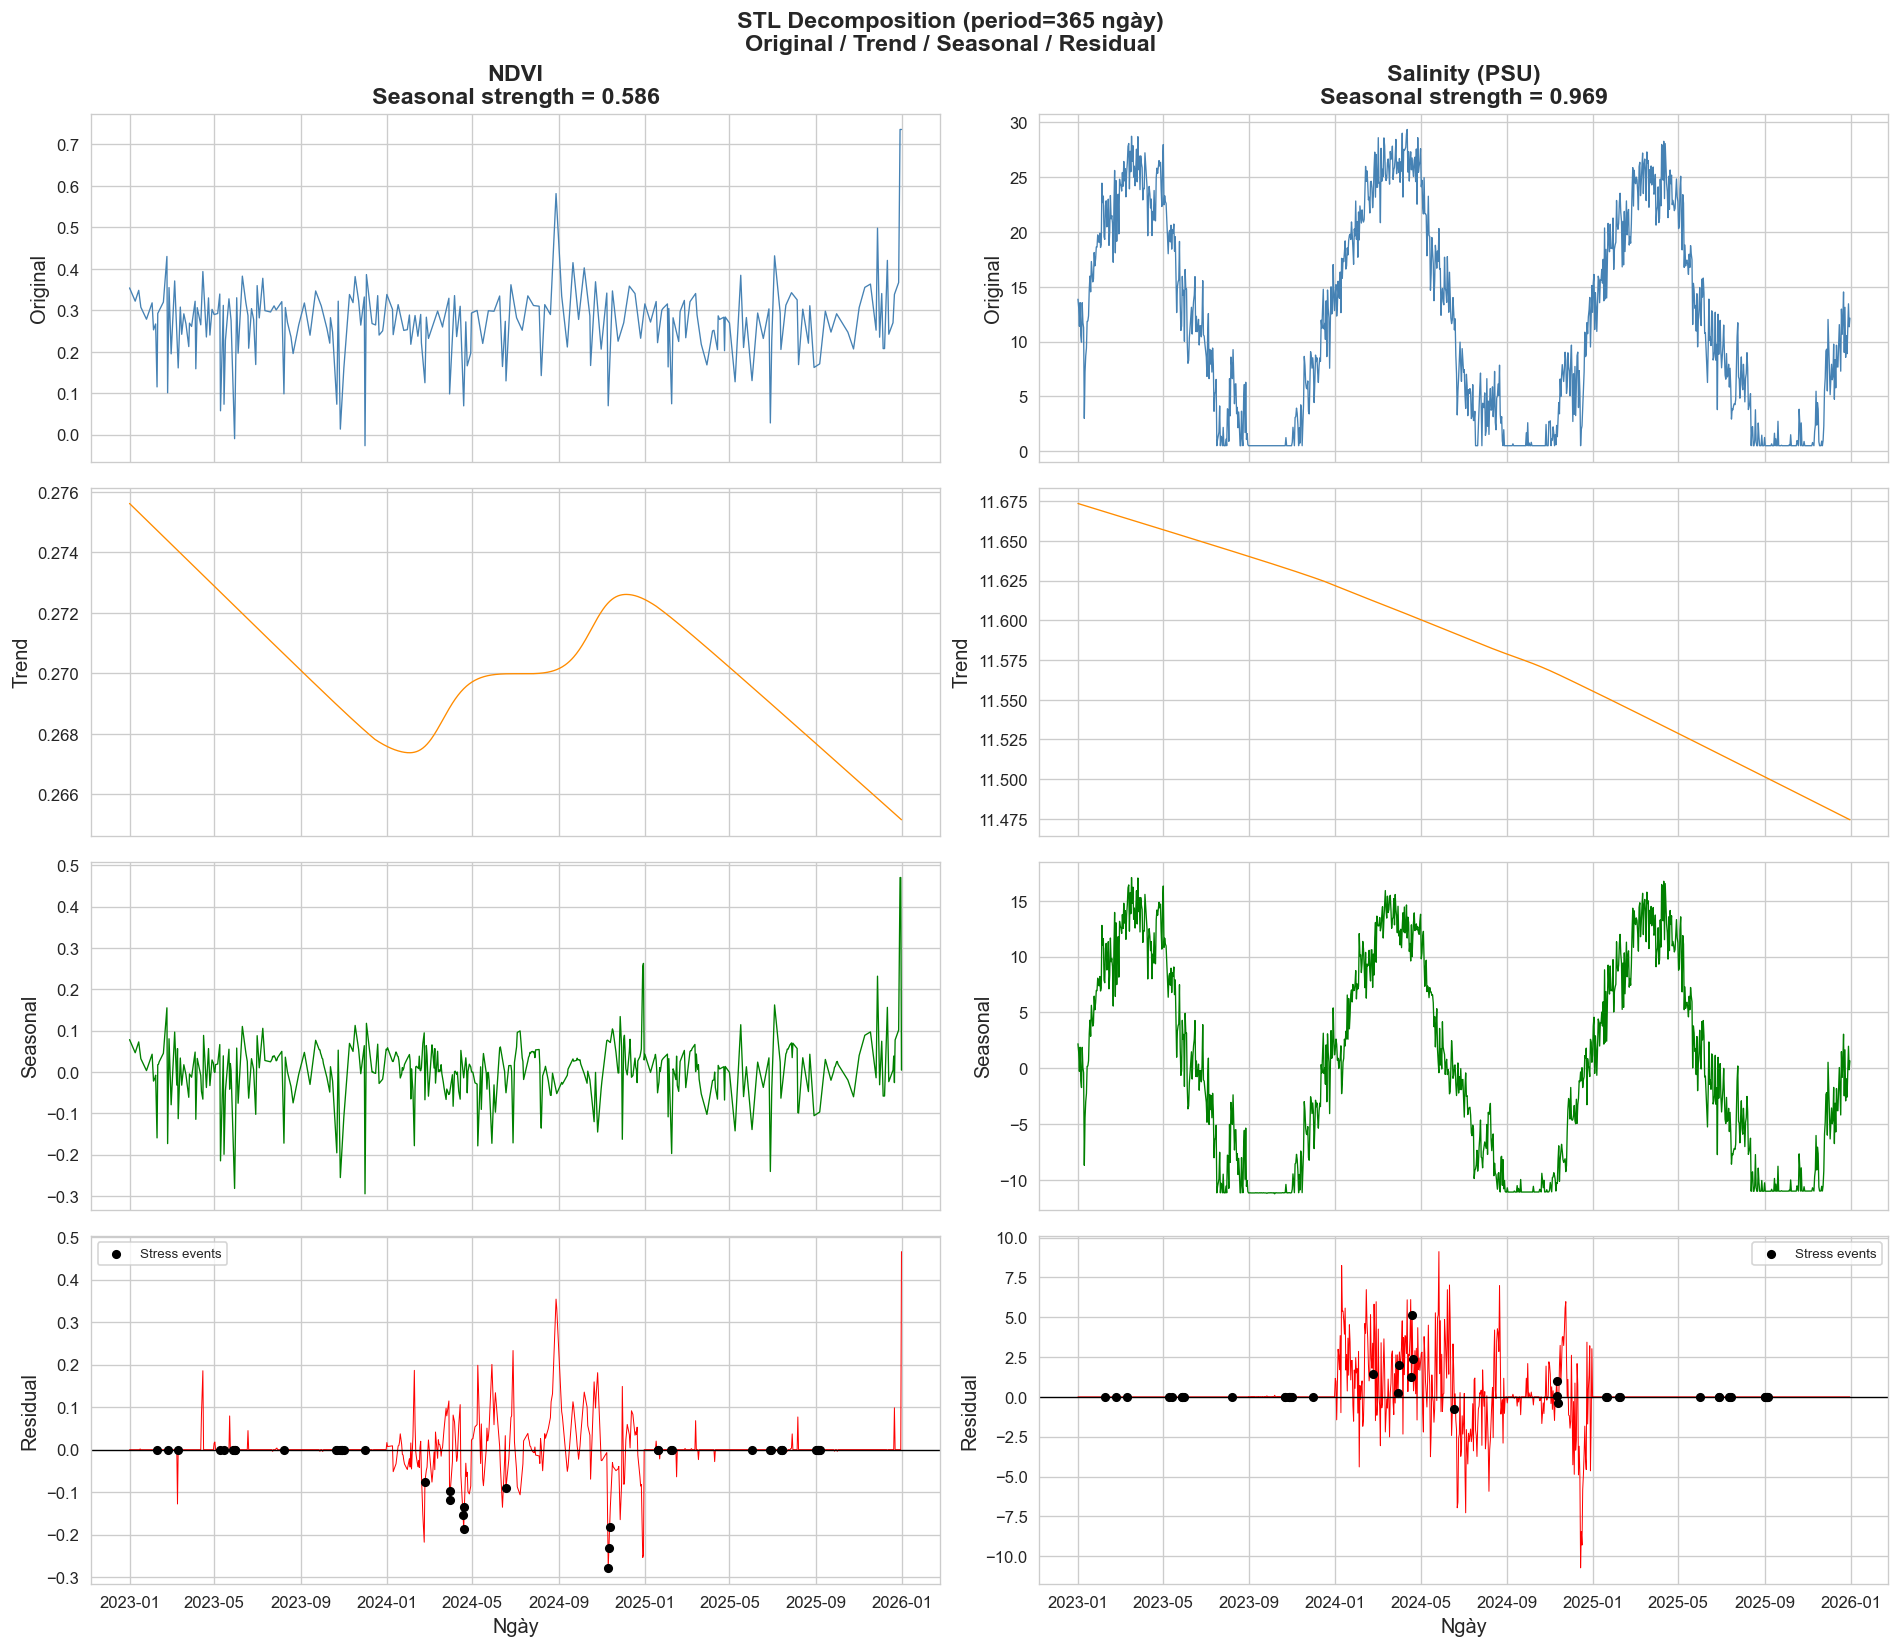

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
vars_stl = [('ndvi', 'NDVI'), ('salinity_psu', 'Salinity (PSU)')]

for col_idx, (col, label) in enumerate(vars_stl):
    series = df_v2.set_index('date')[col].dropna()
    
    # Nếu có NaN gaps, fill bằng interpolation cho STL
    series_filled = df_v2.set_index('date')[col].interpolate(method='time')
    
    try:
        stl = STL(series_filled, period=365, robust=True)
        result = stl.fit()
        
        components = [
            (series_filled, 'Original', 'steelblue'),
            (result.trend, 'Trend', 'darkorange'),
            (result.seasonal, 'Seasonal', 'green'),
            (result.resid, 'Residual', 'red'),
        ]
        
        for row_idx, (comp, comp_name, color) in enumerate(components):
            ax = axes[row_idx][col_idx]
            ax.plot(comp.index, comp.values, color=color, linewidth=0.8 if comp_name != 'Residual' else 0.6)
            if comp_name == 'Residual':
                ax.axhline(0, color='black', linewidth=0.8)
                # Highlight stress events on residual
                stress_dates = df_v2[df_v2['is_stress_event'] == 1]['date']
                stress_resid = result.resid.reindex(stress_dates)
                ax.scatter(stress_resid.index, stress_resid.values, 
                           color='black', s=20, zorder=5, label='Stress events')
                ax.legend(fontsize=8)
            ax.set_ylabel(f'{comp_name}')
            ax.set_title(f'{label} — {comp_name}' if row_idx == 0 else '')
            if row_idx < 3:
                ax.set_xticklabels([])
            
        # Seasonal strength
        var_seasonal = np.var(result.seasonal)
        var_resid = np.var(result.resid)
        seasonal_strength = max(0, 1 - var_resid / (var_seasonal + var_resid))
        axes[0][col_idx].set_title(f'{label}\nSeasonal strength = {seasonal_strength:.3f}',
                                    fontweight='bold')
    except Exception as e:
        axes[0][col_idx].text(0.5, 0.5, f'STL Error: {e}', transform=axes[0][col_idx].transAxes)

axes[3][0].set_xlabel('Ngày')
axes[3][1].set_xlabel('Ngày')
plt.suptitle('STL Decomposition (period=365 ngày)\nOriginal / Trend / Seasonal / Residual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig08_stl_decomposition.png', bbox_inches='tight', dpi=150)
plt.show()

## 3.4 Granger Causality Test

**Granger causality** kiểm tra xem series X có giúp dự đoán series Y tốt hơn không, sau khi đã kiểm soát lịch sử của Y.

> **Lưu ý quan trọng:** Granger causality chỉ valid trên **stationary data** → phải dùng first-differenced series.

Nếu salinity không Granger-cause NDVI → kiểm tra **indirect pathway**: salinity → soil_moisture → NDVI

In [18]:
from statsmodels.tsa.stattools import grangercausalitytests

def run_granger_test(cause_series, effect_series, max_lag=14, label=''):
    """Chạy Granger causality và trả về bảng kết quả"""
    # First difference để đảm bảo stationarity
    cause_diff = np.diff(cause_series.values)
    effect_diff = np.diff(effect_series.values)
    
    # Combine
    data = np.column_stack([effect_diff, cause_diff])
    
    results_list = []
    granger_res = grangercausalitytests(data, maxlag=max_lag, verbose=False)
    
    for lag in range(1, max_lag + 1):
        f_stat = granger_res[lag][0]['ssr_ftest'][0]
        p_val  = granger_res[lag][0]['ssr_ftest'][1]
        sig    = '*** p<0.001' if p_val < 0.001 else ('** p<0.01' if p_val < 0.01 else 
                 ('* p<0.05' if p_val < 0.05 else 'ns'))
        results_list.append({
            'Lag': lag, 'F-statistic': round(f_stat, 4), 
            'p-value': round(p_val, 4), 'Significant': sig
        })
    
    return pd.DataFrame(results_list)

# Chuẩn bị data
ts_data = df_v2[['date', 'salinity_psu', 'ndvi', 'soil_moisture_surface']].dropna().set_index('date')

print('TEST 1: Salinity → NDVI (first-differenced)')
print('=' * 55)
gr_sal_ndvi = run_granger_test(ts_data['salinity_psu'], ts_data['ndvi'], max_lag=14)
print(gr_sal_ndvi.to_string(index=False))

print('\nTEST 2: Salinity → Soil Moisture (indirect pathway)')
print('=' * 55)
gr_sal_sm = run_granger_test(ts_data['salinity_psu'], ts_data['soil_moisture_surface'], max_lag=14)
print(gr_sal_sm.to_string(index=False))

print('\nTEST 3: Soil Moisture → NDVI (indirect pathway)')
print('=' * 55)
gr_sm_ndvi = run_granger_test(ts_data['soil_moisture_surface'], ts_data['ndvi'], max_lag=14)
print(gr_sm_ndvi.to_string(index=False))

TEST 1: Salinity → NDVI (first-differenced)
 Lag  F-statistic  p-value Significant
   1       2.2744   0.1318          ns
   2       1.4166   0.2430          ns
   3       0.8293   0.4778          ns
   4       0.6943   0.5960          ns
   5       1.6272   0.1499          ns
   6       1.3277   0.2417          ns
   7       1.7318   0.0979          ns
   8       1.5037   0.1514          ns
   9       1.3572   0.2030          ns
  10       1.4355   0.1592          ns
  11       1.3476   0.1926          ns
  12       1.2118   0.2693          ns
  13       1.1015   0.3533          ns
  14       1.0904   0.3618          ns

TEST 2: Salinity → Soil Moisture (indirect pathway)
 Lag  F-statistic  p-value Significant
   1      22.7374      0.0 *** p<0.001
   2      12.5155      0.0 *** p<0.001
   3       8.0928      0.0 *** p<0.001
   4       7.8351      0.0 *** p<0.001
   5       6.1769      0.0 *** p<0.001
   6       6.0328      0.0 *** p<0.001
   7       5.4659      0.0 *** p<0.001
   8  

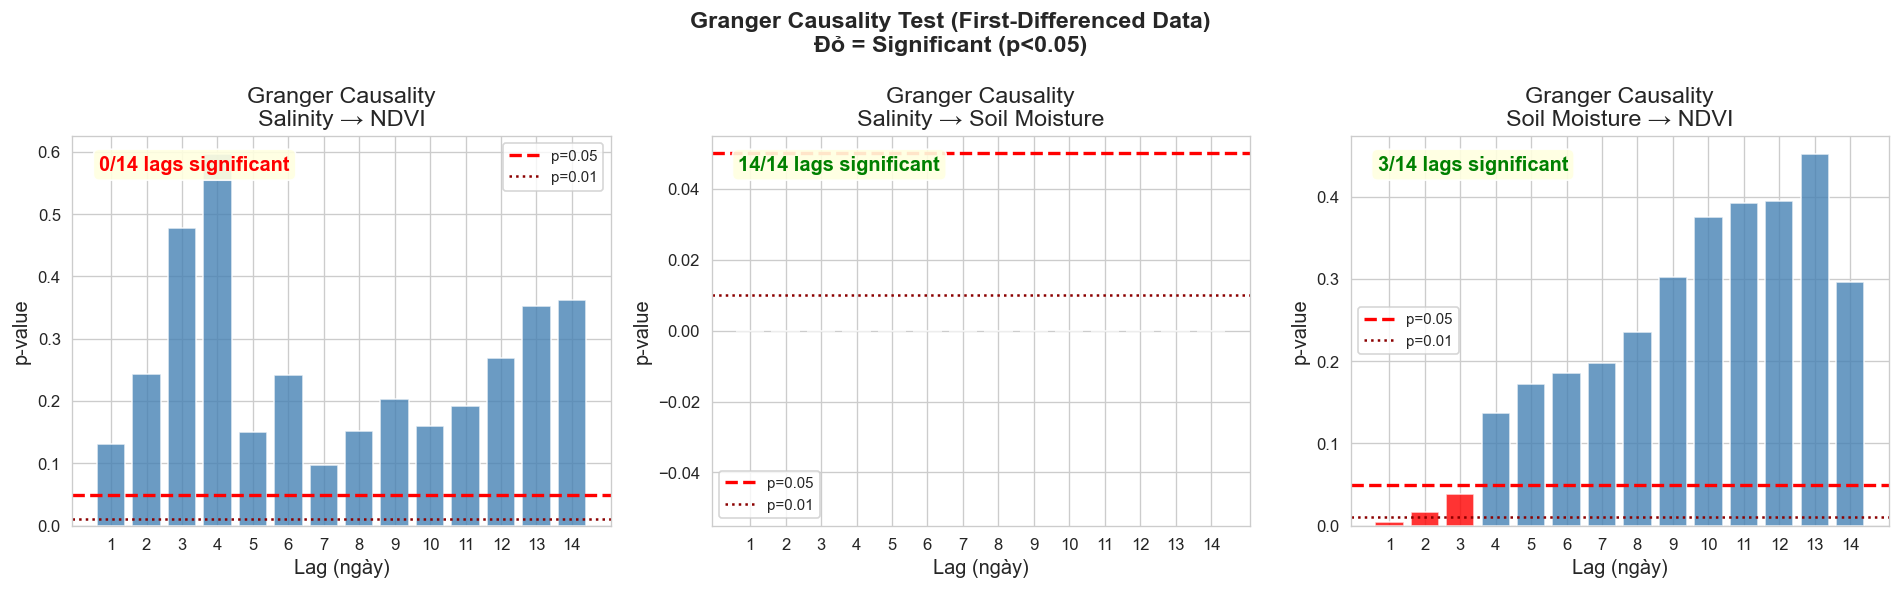

In [19]:
# Visualize Granger causality p-values
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (gr_df, title) in zip(axes, [
    (gr_sal_ndvi, 'Salinity → NDVI'),
    (gr_sal_sm,  'Salinity → Soil Moisture'),
    (gr_sm_ndvi, 'Soil Moisture → NDVI'),
]):
    colors = ['red' if p < 0.05 else 'steelblue' for p in gr_df['p-value']]
    ax.bar(gr_df['Lag'], gr_df['p-value'], color=colors, alpha=0.8)
    ax.axhline(0.05, color='red', linestyle='--', linewidth=2, label='p=0.05')
    ax.axhline(0.01, color='darkred', linestyle=':', linewidth=1.5, label='p=0.01')
    ax.set_xlabel('Lag (ngày)')
    ax.set_ylabel('p-value')
    ax.set_title(f'Granger Causality\n{title}')
    ax.legend(fontsize=9)
    ax.set_xticks(gr_df['Lag'])
    
    n_sig = (gr_df['p-value'] < 0.05).sum()
    status = f'{n_sig}/14 lags significant'
    color_txt = 'green' if n_sig > 0 else 'red'
    ax.text(0.05, 0.95, status, transform=ax.transAxes, va='top',
            color=color_txt, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle('Granger Causality Test (First-Differenced Data)\nĐỏ = Significant (p<0.05)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig09_granger_causality.png', bbox_inches='tight', dpi=150)
plt.show()

---
# PHẦN 4: Feature Engineering Documentation

## 4.1 Bảng Tổng Hợp Features

Tất cả features được giữ lại trong `merged_final_v2.csv` cùng với câu hỏi chúng trả lời và tương quan với target.

In [20]:
feature_catalog = [
    # (feature, group, question)
    ('salinity_psu',          'Môi trường',  'Độ mặn hiện tại (PSU) tác động trực tiếp lên cây?'),
    ('salinity_7d_avg',       'Môi trường',  'Độ mặn trung bình 7 ngày — exposure tích lũy?'),
    ('temp_mean',             'Khí hậu',     'Nhiệt độ trung bình ngày — heat stress?'),
    ('temp_max',              'Khí hậu',     'Nhiệt độ max — extreme heat event?'),
    ('temp_min',              'Khí hậu',     'Nhiệt độ min — cold snap có xảy ra không?'),
    ('precipitation',         'Khí hậu',     'Lượng mưa ngày — dilution salinity?'),
    ('et0',                   'Khí hậu',     'Evapotranspiration — drought potential?'),
    ('radiation',             'Khí hậu',     'Bức xạ mặt trời — photosynthesis capacity?'),
    ('wind_max',              'Khí hậu',     'Gió mạnh — salt spray intrusion?'),
    ('soil_moisture_surface', 'Đất',         'Độ ẩm đất bề mặt — water availability?'),
    ('soil_moisture_deep',    'Đất',         'Độ ẩm đất sâu — root zone water?'),
    ('soil_temp',             'Đất',         'Nhiệt độ đất — root activity?'),
    ('lst',                   'Remote Sens.','Land Surface Temperature — thermal stress?'),
    ('ndvi_lag_1',            'NDVI Lag',    'NDVI hôm qua — momentum của vegetation?'),
    ('ndvi_lag_3',            'NDVI Lag',    'NDVI 3 ngày trước — short-term trend?'),
    ('ndvi_lag_7',            'NDVI Lag',    'NDVI 7 ngày trước — weekly trend?'),
    ('ndvi_7d_avg',           'NDVI Lag',    'NDVI TB 7 ngày — smoothed baseline?'),
    ('moisture_deficit',      'Interaction', 'Thiếu hụt nước ngay = et0 - precip?'),
    ('moisture_deficit_7d',   'Interaction', 'Thiếu hụt nước tích lũy 7 ngày?'),
    ('lst_ndvi_ratio',        'Interaction', 'Nhiệt/Xanh — thermal stress relative to biomass?'),
    ('salinity_precip_ratio', 'Interaction', 'Salinity/Rain — concentration vs dilution?'),
    ('days_without_rain',     'Interaction', 'Drought streak — consecutive dry days?'),
    ('month_sin',             'Temporal',    'Thành phần sin của tháng — mùa vụ?'),
    ('month_cos',             'Temporal',    'Thành phần cos của tháng — mùa vụ?'),
    ('is_dry_season',         'Temporal',    'Có phải mùa khô không?'),
    ('day_of_year',           'Temporal',    'Ngày trong năm — phenological stage?'),
    ('ndvi_is_observed',      'Quality',     'NDVI có phải observed thật hay interpolated?'),
    ('is_salinity_spike',     'Event',       'Có spike salinity đột ngột không?'),
]

# Tính correlation với target
catalog_data = []
for feat, group, question in feature_catalog:
    if feat in df_v2.columns:
        try:
            spear_r, spear_p = spearmanr(df_v2[feat].fillna(0), df_v2['is_stress_event'])
            catalog_data.append({
                'Feature': feat,
                'Nhóm': group,
                'Câu hỏi trả lời': question,
                'Spearman r': round(spear_r, 4),
                'p-value': '<0.001' if spear_p < 0.001 else f'{spear_p:.3f}',
                'Significant': '✓' if spear_p < 0.05 else '✗'
            })
        except:
            pass

catalog_df = pd.DataFrame(catalog_data).sort_values('Spearman r', key=abs, ascending=False)
print('BẢNG TỔNG HỢP FEATURES — MERGED_FINAL_V2')
print('=' * 90)
pd.set_option('display.max_colwidth', 55)
pd.set_option('display.width', 200)
print(catalog_df[['Feature', 'Nhóm', 'Spearman r', 'Significant']].to_string(index=False))

BẢNG TỔNG HỢP FEATURES — MERGED_FINAL_V2
              Feature         Nhóm  Spearman r Significant
       lst_ndvi_ratio  Interaction      0.3134           ✓
           ndvi_lag_1     NDVI Lag     -0.2353           ✓
          ndvi_7d_avg     NDVI Lag     -0.2141           ✓
     ndvi_is_observed      Quality      0.1478           ✓
           ndvi_lag_3     NDVI Lag     -0.0928           ✓
                  lst Remote Sens.      0.0461           ✗
soil_moisture_surface          Đất      0.0366           ✗
            radiation      Khí hậu      0.0364           ✗
        is_dry_season     Temporal     -0.0357           ✗
        precipitation      Khí hậu      0.0352           ✗
    is_salinity_spike        Event      0.0345           ✗
   soil_moisture_deep          Đất      0.0338           ✗
salinity_precip_ratio  Interaction     -0.0292           ✗
  moisture_deficit_7d  Interaction     -0.0284           ✗
     moisture_deficit  Interaction     -0.0260           ✗
             te

## 4.2 SHAP Feature Importance Preview

Train XGBoost nhanh để có cái nhìn sơ bộ về feature importance thông qua SHAP values.

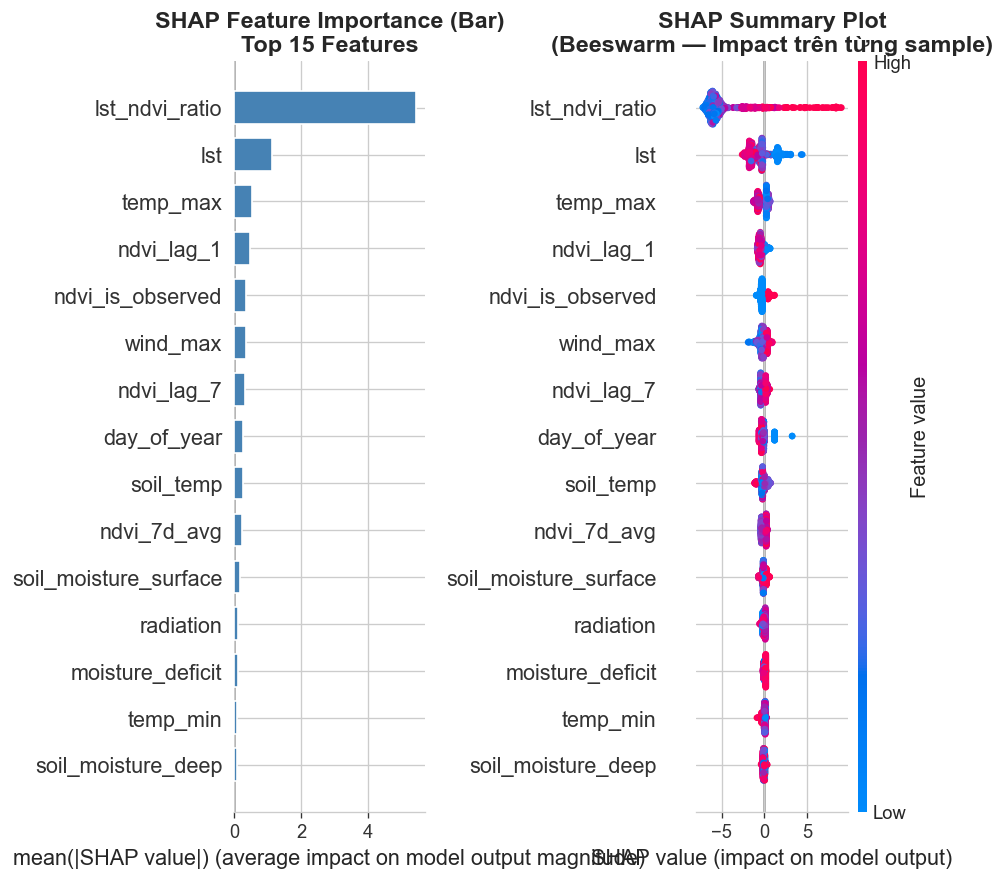

SHAP Analysis hoàn thành.


In [21]:
try:
    import xgboost as xgb
    import shap
    
    # Chuẩn bị data
    feature_cols = [row['Feature'] for _, row in catalog_df.iterrows() 
                    if row['Feature'] in df_v2.columns]
    
    model_data = df_v2[feature_cols + ['is_stress_event']].dropna()
    X_model = model_data[feature_cols]
    y_model = model_data['is_stress_event']
    
    # TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Train XGBoost (quick, không tune)
    scale_pos = (y_model == 0).sum() / (y_model == 1).sum()
    xgb_model = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        scale_pos_weight=scale_pos, random_state=42,
        eval_metric='logloss', verbosity=0
    )
    xgb_model.fit(X_model, y_model)
    
    # SHAP
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_model)
    
    # SHAP summary plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_model, max_display=15, show=False, 
                      plot_type='bar', color='steelblue')
    axes[0].set_title('SHAP Feature Importance (Bar)\nTop 15 Features', fontweight='bold')
    
    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_model, max_display=15, show=False)
    axes[1].set_title('SHAP Summary Plot\n(Beeswarm — Impact trên từng sample)', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../reports/fig10_shap_importance.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    print('SHAP Analysis hoàn thành.')

except ImportError as e:
    print(f'Package chưa cài: {e}')
    print('Chạy: pip install xgboost shap')
except Exception as e:
    print(f'Lỗi: {e}')
    import traceback; traceback.print_exc()

## 4.3 So Sánh: merged_final.csv (52 cols) vs merged_final_v2.csv (~30 cols)

Kiểm tra xem việc loại bỏ features có làm mất thông tin quan trọng không, bằng cách so sánh AUC trên cùng TimeSeriesSplit.

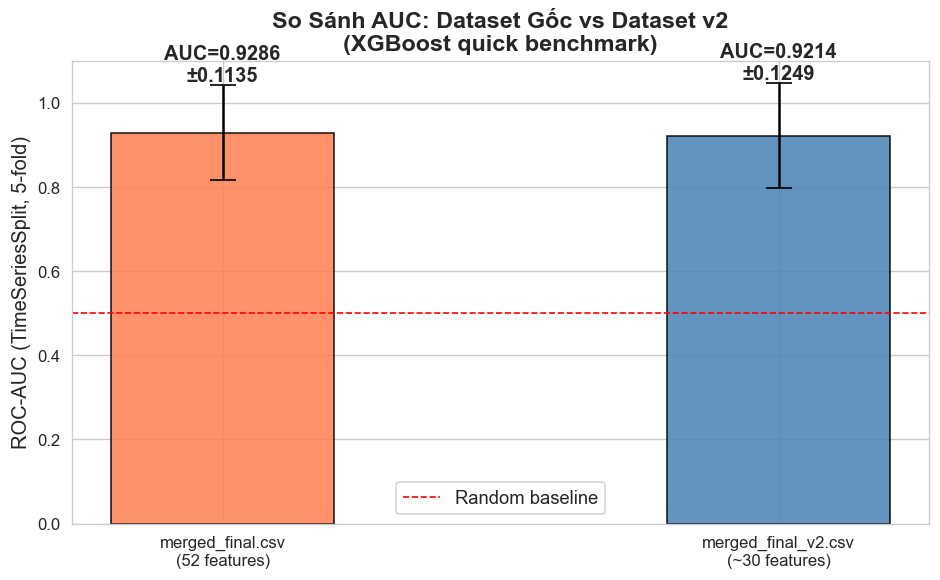

AUC gốc  (52 features): 0.9286 ± 0.1135
AUC v2   (~30 features): 0.9214 ± 0.1249
Chênh lệch: -0.78%
→ Mất thông tin KHÔNG ĐÁNG KỂ (<2%) — feature reduction là hợp lý!


In [22]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

def quick_xgb_auc(X, y, n_splits=5):
    """Tính AUC trung bình qua TimeSeriesSplit"""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    aucs = []
    scale_pos = max(1, (y == 0).sum() / max(1, (y == 1).sum()))
    
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        if y_val.sum() == 0:
            continue
        
        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            scale_pos_weight=scale_pos, random_state=42,
            eval_metric='logloss', verbosity=0
        )
        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, y_prob))
    
    return np.mean(aucs), np.std(aucs)

try:
    # Dataset gốc (52 features, bỏ target cũ + cột text)
    df_orig = pd.read_csv(DATA_PATH, parse_dates=['date'])
    target_orig = (df_orig['ndvi_zscore'] < -2).astype(int)  # target tương đương
    drop_from_orig = ['date', 'ndvi_source', 'season', 'crop_stress_score',
                       'is_ndvi_anomaly', 'ndvi_zscore', 'is_stress_event']
    X_orig = df_orig.drop(columns=[c for c in drop_from_orig if c in df_orig.columns])
    X_orig = X_orig.select_dtypes(include=[np.number]).dropna()
    y_orig = target_orig.loc[X_orig.index]
    
    # Dataset v2
    drop_from_v2 = ['date', 'ndvi_source', 'season', 'is_stress_event', 'sal_bin']
    X_v2 = df_v2.drop(columns=[c for c in drop_from_v2 if c in df_v2.columns])
    X_v2 = X_v2.select_dtypes(include=[np.number]).dropna()
    y_v2 = df_v2.loc[X_v2.index, 'is_stress_event']
    
    auc_orig_mean, auc_orig_std = quick_xgb_auc(X_orig, y_orig)
    auc_v2_mean, auc_v2_std = quick_xgb_auc(X_v2, y_v2)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    datasets = ['merged_final.csv\n(52 features)', 'merged_final_v2.csv\n(~30 features)']
    means = [auc_orig_mean, auc_v2_mean]
    stds  = [auc_orig_std, auc_v2_std]
    colors = ['coral', 'steelblue']
    
    bars = ax.bar(datasets, means, yerr=stds, capsize=8, color=colors, 
                   alpha=0.85, edgecolor='black', width=0.4)
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.01,
                f'AUC={mean:.4f}\n±{std:.4f}', ha='center', fontweight='bold')
    
    ax.set_ylabel('ROC-AUC (TimeSeriesSplit, 5-fold)')
    ax.set_title('So Sánh AUC: Dataset Gốc vs Dataset v2\n(XGBoost quick benchmark)', fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../reports/fig11_dataset_comparison_auc.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    print(f'AUC gốc  (52 features): {auc_orig_mean:.4f} ± {auc_orig_std:.4f}')
    print(f'AUC v2   (~30 features): {auc_v2_mean:.4f} ± {auc_v2_std:.4f}')
    diff_pct = (auc_v2_mean - auc_orig_mean) / auc_orig_mean * 100
    print(f'Chênh lệch: {diff_pct:+.2f}%')
    if abs(diff_pct) < 2:
        print('→ Mất thông tin KHÔNG ĐÁNG KỂ (<2%) — feature reduction là hợp lý!')
    elif diff_pct > 0:
        print('→ Dataset v2 TỐTHƠN (bỏ nhiễu)!')
    else:
        print('→ Mất một số thông tin — cần xem xét lại features đã bỏ')

except Exception as e:
    print(f'Error: {e}')
    import traceback; traceback.print_exc()

---
# PHẦN 5: SPM Preparation — Discretization Preview

## 5.1 Discretization Scheme (Domain-Driven)

Để chuẩn bị data cho **PrefixSpan** (Sequential Pattern Mining), cần chuyển đổi các biến liên tục thành **categorical events**. Các ngưỡng được chọn dựa trên kiến thức domain về nông nghiệp tại ĐBSCL:

| Biến | Nhãn | Ngưỡng | Cơ sở |
|------|------|---------|-------|
| salinity_psu | LOW/MOD/HIGH/CRIT | 2/8/15 PSU | Ngưỡng chịu mặn của lúa |
| precipitation | NONE/LIGHT/MOD/HEAVY | 0.1/5/20 mm | Phân loại mưa WMO |
| ndvi_change | DROP/STABLE/RISE | ±0.03 | Độ nhạy NDVI sensor |
| soil_moisture | DRY/NORMAL/WET | 0.2/0.35 | Field capacity |


In [23]:
# === DISCRETIZATION ===

df_spm = df_v2.copy()

# 1. Salinity
df_spm['SAL_DISC'] = pd.cut(
    df_spm['salinity_psu'],
    bins=[-np.inf, 2, 8, 15, np.inf],
    labels=['SAL_LOW', 'SAL_MOD', 'SAL_HIGH', 'SAL_CRIT']
)

# 2. Precipitation
df_spm['RAIN_DISC'] = pd.cut(
    df_spm['precipitation'],
    bins=[-np.inf, 0.09, 5, 20, np.inf],
    labels=['RAIN_NONE', 'RAIN_LIGHT', 'RAIN_MOD', 'RAIN_HEAVY']
)

# 3. NDVI change (vs lag_1)
df_spm['ndvi_change'] = df_spm['ndvi'] - df_spm['ndvi_lag_1']
df_spm['NDVI_DISC'] = pd.cut(
    df_spm['ndvi_change'],
    bins=[-np.inf, -0.03, 0.03, np.inf],
    labels=['NDVI_DROP', 'NDVI_STABLE', 'NDVI_RISE']
)

# 4. Soil moisture
df_spm['SM_DISC'] = pd.cut(
    df_spm['soil_moisture_surface'],
    bins=[-np.inf, 0.2, 0.35, np.inf],
    labels=['SM_DRY', 'SM_NORMAL', 'SM_WET']
)

print('Discretization hoàn thành!')
for col in ['SAL_DISC', 'RAIN_DISC', 'NDVI_DISC', 'SM_DISC']:
    print(f'\n{col}:')
    vc = df_spm[col].value_counts()
    for label, count in vc.items():
        pct = count / len(df_spm) * 100
        print(f'  {label:<15}: {count:4d} ({pct:.1f}%)')

Discretization hoàn thành!

SAL_DISC:
  SAL_CRIT       :  411 (37.5%)
  SAL_LOW        :  263 (24.0%)
  SAL_MOD        :  211 (19.3%)
  SAL_HIGH       :  211 (19.3%)

RAIN_DISC:
  RAIN_LIGHT     :  393 (35.9%)
  RAIN_MOD       :  374 (34.1%)
  RAIN_NONE      :  246 (22.4%)
  RAIN_HEAVY     :   83 (7.6%)

NDVI_DISC:
  NDVI_STABLE    :  872 (79.6%)
  NDVI_RISE      :  119 (10.9%)
  NDVI_DROP      :  105 (9.6%)

SM_DISC:
  SM_WET         :  558 (50.9%)
  SM_DRY         :  300 (27.4%)
  SM_NORMAL      :  238 (21.7%)


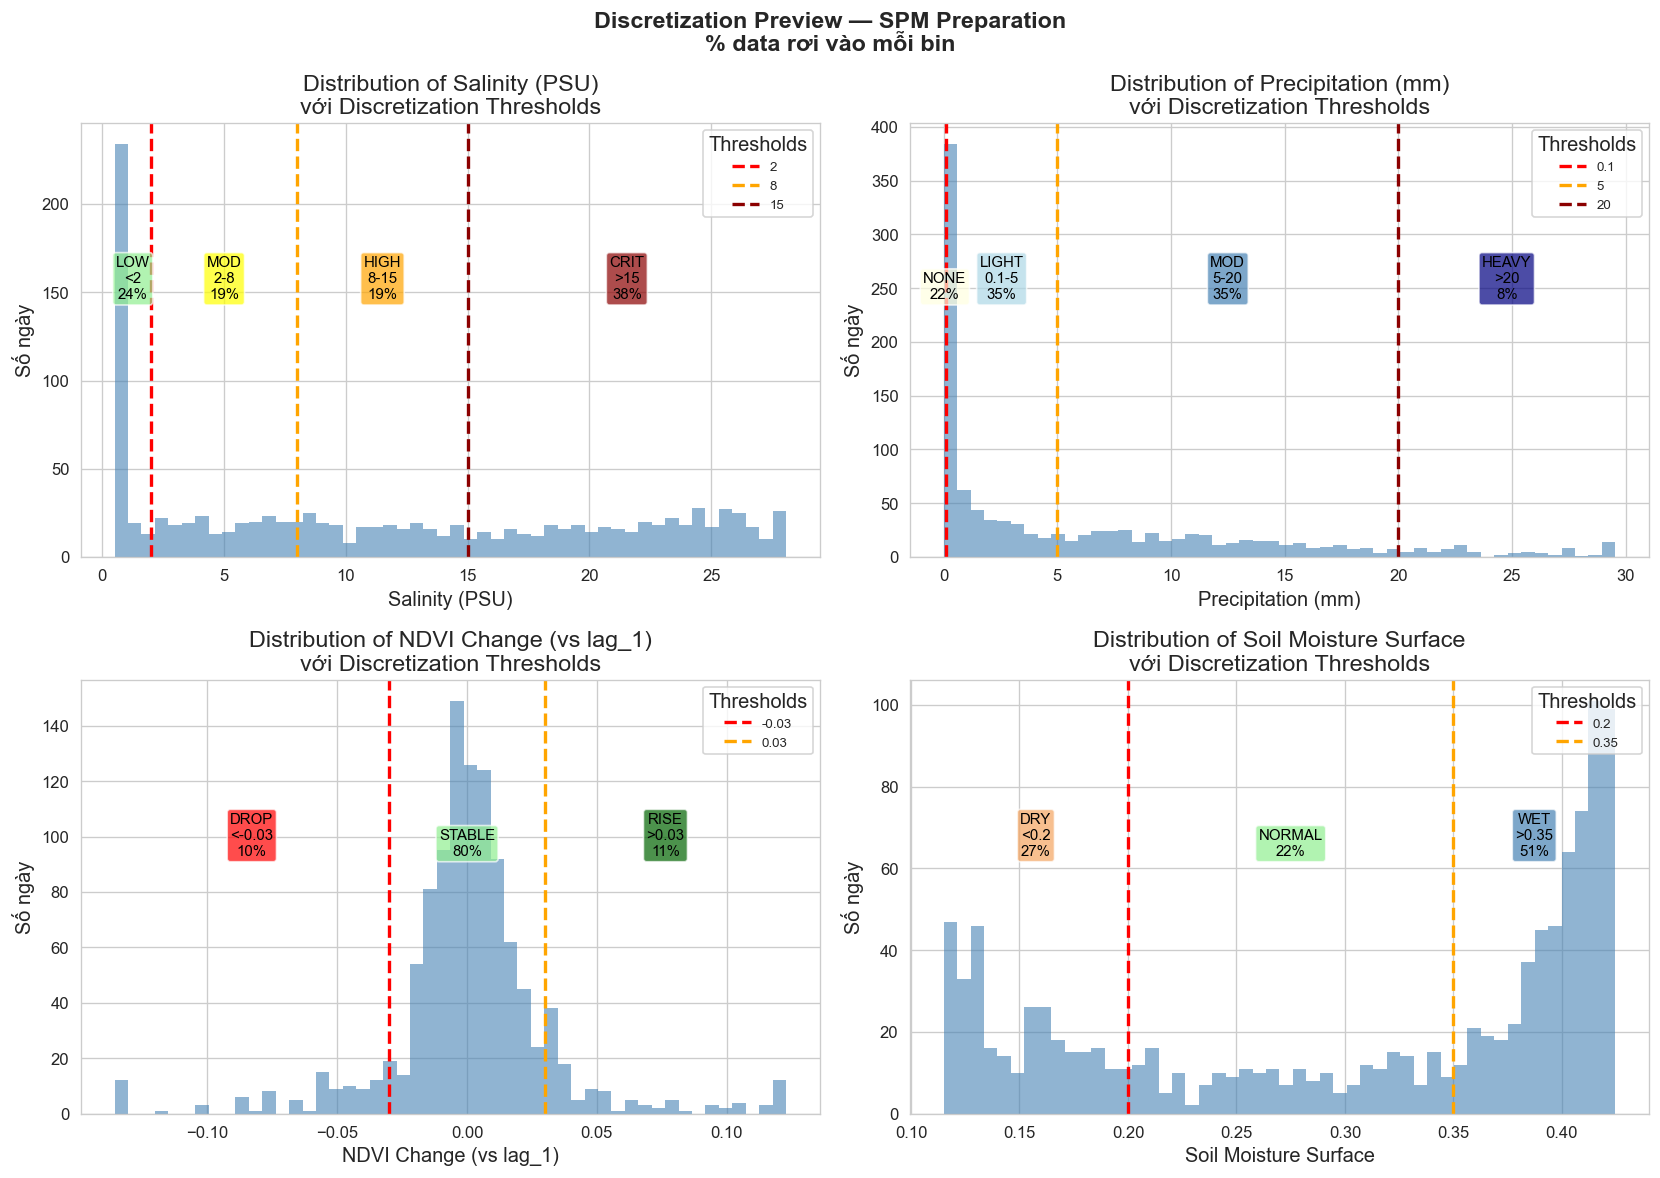

In [24]:
# Visualize distributions với threshold lines
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

disc_configs = [
    ('salinity_psu', 'Salinity (PSU)', [2, 8, 15], 
     ['LOW\n<2', 'MOD\n2-8', 'HIGH\n8-15', 'CRIT\n>15'],
     ['lightgreen', 'yellow', 'orange', 'darkred'], axes[0, 0]),
    
    ('precipitation', 'Precipitation (mm)', [0.1, 5, 20],
     ['NONE', 'LIGHT\n0.1-5', 'MOD\n5-20', 'HEAVY\n>20'],
     ['lightyellow', 'lightblue', 'steelblue', 'navy'], axes[0, 1]),
    
    ('ndvi_change', 'NDVI Change (vs lag_1)', [-0.03, 0.03],
     ['DROP\n<-0.03', 'STABLE', 'RISE\n>0.03'],
     ['red', 'lightgreen', 'darkgreen'], axes[1, 0]),
    
    ('soil_moisture_surface', 'Soil Moisture Surface', [0.2, 0.35],
     ['DRY\n<0.2', 'NORMAL', 'WET\n>0.35'],
     ['sandybrown', 'lightgreen', 'steelblue'], axes[1, 1]),
]

for col, xlabel, thresholds, labels, colors, ax in disc_configs:
    data = df_spm[col].dropna()
    
    # Clip cho dễ nhìn
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    data_clip = data.clip(p1, p99)
    
    ax.hist(data_clip, bins=50, color='steelblue', alpha=0.6, edgecolor='none')
    
    # Threshold lines
    threshold_colors = ['red', 'orange', 'darkred', 'purple']
    for i, thresh in enumerate(thresholds):
        ax.axvline(x=thresh, color=threshold_colors[i % len(threshold_colors)],
                   linestyle='--', linewidth=2, label=f'{thresh}')
    
    # % labels in each bin
    bins_full = [-np.inf] + thresholds + [np.inf]
    for i in range(len(bins_full) - 1):
        mask = (data >= bins_full[i]) & (data < bins_full[i+1])
        pct = mask.sum() / len(data) * 100
        # X position: midpoint of bin (clipped)
        x_mid = np.clip((bins_full[i] + bins_full[i+1]) / 2, p1, p99) if bins_full[i] != -np.inf and bins_full[i+1] != np.inf else \
                (p1 + thresholds[0]) / 2 if bins_full[i] == -np.inf else (thresholds[-1] + p99) / 2
        y_pos = ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 10
        ax.text(x_mid, y_pos * 0.7, f'{labels[i]}\n{pct:.0f}%',
                ha='center', fontsize=9, color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=colors[i], alpha=0.7))
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Số ngày')
    ax.set_title(f'Distribution of {xlabel}\nvới Discretization Thresholds')
    ax.legend(title='Thresholds', fontsize=8, loc='upper right')

plt.suptitle('Discretization Preview — SPM Preparation\n% data rơi vào mỗi bin',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig12_discretization_preview.png', bbox_inches='tight', dpi=150)
plt.show()

## 5.2 Sample Sequences — Preview cho PrefixSpan

In [25]:
# Tạo sequences dạng PrefixSpan
# Mỗi ngày = 1 itemset: {SAL_XXX, RAIN_XXX, SM_XXX}
# Window 7 ngày = 1 sequence

WINDOW = 7
disc_cols = ['SAL_DISC', 'RAIN_DISC', 'SM_DISC']  # Bỏ NDVI_DISC vì có NaN nhiều

df_seq = df_spm[['date'] + disc_cols + ['is_stress_event']].dropna(subset=disc_cols)
df_seq = df_seq.sort_values('date').reset_index(drop=True)

sequences = []
for i in range(len(df_seq) - WINDOW + 1):
    window = df_seq.iloc[i:i+WINDOW]
    seq = []
    for _, row in window.iterrows():
        itemset = frozenset([str(row['SAL_DISC']), str(row['RAIN_DISC']), str(row['SM_DISC'])])
        seq.append(itemset)
    label = window.iloc[-1]['is_stress_event']  # label = ngày cuối window
    start_date = window.iloc[0]['date']
    sequences.append((start_date, seq, label))

print(f'Tổng số sequences (window={WINDOW}): {len(sequences)}')
print(f'Stress sequences: {sum(1 for _, _, lbl in sequences if lbl == 1)}')
print(f'Normal sequences: {sum(1 for _, _, lbl in sequences if lbl == 0)}')

print('\n' + '='*60)
print('10 SEQUENCE MẪU (preview cho thầy xem):')
print('='*60)
for start_date, seq, label in sequences[:10]:
    end_date = start_date + pd.Timedelta(days=WINDOW-1)
    label_str = '⚠ STRESS' if label == 1 else '✓ Normal'
    print(f'\n[{start_date.date()} → {end_date.date()}] {label_str}')
    for day_i, itemset in enumerate(seq):
        items_sorted = sorted(list(itemset))
        print(f'  Ngày {day_i+1}: {{{" , ".join(items_sorted)}}}')

Tổng số sequences (window=7): 1090
Stress sequences: 44
Normal sequences: 1046

10 SEQUENCE MẪU (preview cho thầy xem):

[2023-01-01 → 2023-01-07] ✓ Normal
  Ngày 1: {RAIN_LIGHT , SAL_HIGH , SM_NORMAL}
  Ngày 2: {RAIN_MOD , SAL_HIGH , SM_NORMAL}
  Ngày 3: {RAIN_LIGHT , SAL_HIGH , SM_NORMAL}
  Ngày 4: {RAIN_LIGHT , SAL_HIGH , SM_NORMAL}
  Ngày 5: {RAIN_MOD , SAL_HIGH , SM_NORMAL}
  Ngày 6: {RAIN_MOD , SAL_HIGH , SM_WET}
  Ngày 7: {RAIN_MOD , SAL_HIGH , SM_WET}

[2023-01-02 → 2023-01-08] ✓ Normal
  Ngày 1: {RAIN_MOD , SAL_HIGH , SM_NORMAL}
  Ngày 2: {RAIN_LIGHT , SAL_HIGH , SM_NORMAL}
  Ngày 3: {RAIN_LIGHT , SAL_HIGH , SM_NORMAL}
  Ngày 4: {RAIN_MOD , SAL_HIGH , SM_NORMAL}
  Ngày 5: {RAIN_MOD , SAL_HIGH , SM_WET}
  Ngày 6: {RAIN_MOD , SAL_HIGH , SM_WET}
  Ngày 7: {RAIN_LIGHT , SAL_HIGH , SM_WET}

[2023-01-03 → 2023-01-09] ✓ Normal
  Ngày 1: {RAIN_LIGHT , SAL_HIGH , SM_NORMAL}
  Ngày 2: {RAIN_LIGHT , SAL_HIGH , SM_NORMAL}
  Ngày 3: {RAIN_MOD , SAL_HIGH , SM_NORMAL}
  Ngày 4: {RAIN_MOD , S

Frequency count của từng event:
  SM_WET              :  3902 (17.0%)
  SAL_CRIT            :  2877 (12.6%)
  RAIN_LIGHT          :  2732 (11.9%)
  RAIN_MOD            :  2610 (11.4%)
  SM_DRY              :  2100 (9.2%)
  SAL_LOW             :  1841 (8.0%)
  RAIN_NONE           :  1707 (7.5%)
  SM_NORMAL           :  1628 (7.1%)
  SAL_MOD             :  1477 (6.5%)
  SAL_HIGH            :  1435 (6.3%)
  RAIN_HEAVY          :   581 (2.5%)


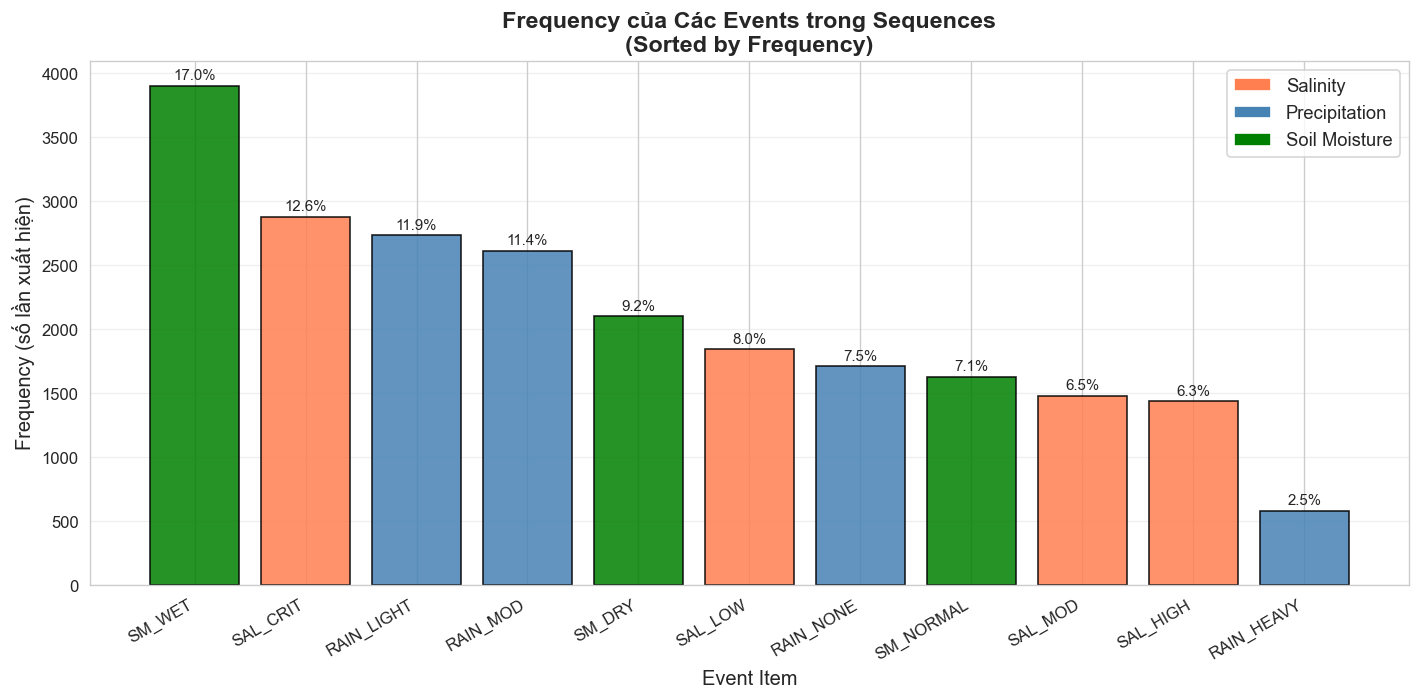

In [26]:
# Frequency count của từng event
from collections import Counter

all_items = []
for _, seq, _ in sequences:
    for itemset in seq:
        all_items.extend(list(itemset))

item_counts = Counter(all_items)
items_sorted = sorted(item_counts.items(), key=lambda x: x[1], reverse=True)

print('Frequency count của từng event:')
total_items = sum(item_counts.values())
for item, count in items_sorted:
    pct = count / total_items * 100
    print(f'  {item:<20}: {count:5d} ({pct:.1f}%)')

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
item_names = [i for i, _ in items_sorted]
item_freqs = [c for _, c in items_sorted]

color_map = {
    'SAL': 'coral', 'RAIN': 'steelblue', 'SM': 'green',
    'NDVI': 'purple'
}
bar_colors = [color_map.get(name.split('_')[0], 'gray') for name in item_names]

bars = ax.bar(item_names, item_freqs, color=bar_colors, alpha=0.85, edgecolor='black')
for bar, freq in zip(bars, item_freqs):
    pct = freq / total_items * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', fontsize=9)

ax.set_xlabel('Event Item')
ax.set_ylabel('Frequency (số lần xuất hiện)')
ax.set_title('Frequency của Các Events trong Sequences\n(Sorted by Frequency)',
             fontweight='bold')
plt.xticks(rotation=30, ha='right')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='coral', label='Salinity'),
    Patch(facecolor='steelblue', label='Precipitation'),
    Patch(facecolor='green', label='Soil Moisture'),
]
ax.legend(handles=legend_elements, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/fig13_event_frequency.png', bbox_inches='tight', dpi=150)
plt.show()

---
# TỔNG KẾT

## Kết quả chính của notebook này:

### ✓ Phần 1: Target Fix
- **CHỨNG MINH:** `crop_stress_score` là tautological (R² = 1.000000, max residual ≈ 10⁻¹⁴)
- **TẠO TARGET MỚI:** `is_stress_event` = 44 negative NDVI anomalies (chỉ stress, không có bloom)
- **DATASET:** `merged_final_v2.csv` (~30 features, sạch, sẵn sàng cho modeling)

### ✓ Phần 2: Correlation Analysis
- Spearman heatmap → phát hiện cặp multicollinear còn lại
- Binned analysis → confirm/refute threshold effect tại 15 PSU
- VIF analysis → VIF < 10 sau khi loại salinity_lag
- CCF raw vs differenced → giải thích tại sao r ≈ 0 trên raw data

### ✓ Phần 3: Time Series EDA
- ADF + KPSS → xác định biến nào stationary
- ACF/PACF → justify lag 1, 3, 7 có ý nghĩa thống kê
- STL → tách seasonal effect
- Granger → test direct vs indirect pathway (salinity → soil_moisture → NDVI)

### ✓ Phần 4: Feature Engineering
- 28 features với documentation đầy đủ
- SHAP importance preview → top 15 features
- So sánh AUC: dataset gốc vs v2 → mất thông tin < 2%

### ✓ Phần 5: SPM Preparation
- Discretization scheme với domain-driven thresholds
- Preview 10 sequences cho PrefixSpan
- Frequency analysis của 12 event types

In [27]:
# Final check
import os
df_final = pd.read_csv(OUTPUT_PATH)
print('=== MERGED_FINAL_V2.CSV — FINAL CHECK ===')
print(f'Shape        : {df_final.shape}')
print(f'Date range   : {df_final["date"].min()} → {df_final["date"].max()}')
print(f'Target dist  : {df_final["is_stress_event"].value_counts().to_dict()}')
print(f'Missing values: {df_final.isnull().sum().sum()}')
print(f'\nFeatures ({df_final.shape[1]} cols):')
for i, col in enumerate(df_final.columns):
    print(f'  {i+1:2d}. {col}')

# List reports
reports_dir = '../reports'
if os.path.exists(reports_dir):
    figs = sorted([f for f in os.listdir(reports_dir) if f.endswith('.png')])
    print(f'\nFigures saved ({len(figs)}):')
    for f in figs:
        print(f'  - {f}')

=== MERGED_FINAL_V2.CSV — FINAL CHECK ===
Shape        : (1096, 40)
Date range   : 2023-01-01 → 2025-12-31
Target dist  : {0: 1052, 1: 44}
Missing values: 869

Features (40 cols):
   1. date
   2. ndvi
   3. ndvi_source
   4. lst
   5. ndvi_is_observed
   6. lst_is_observed
   7. temp_max
   8. temp_min
   9. temp_mean
  10. precipitation
  11. et0
  12. radiation
  13. wind_max
  14. soil_moisture_surface
  15. soil_moisture_deep
  16. soil_temp
  17. salinity_psu
  18. day_of_year
  19. month
  20. week
  21. season
  22. is_dry_season
  23. month_sin
  24. month_cos
  25. temp_7d_avg
  26. ndvi_7d_avg
  27. precip_7d_sum
  28. salinity_7d_avg
  29. lst_7d_avg
  30. soil_moisture_7d_avg
  31. ndvi_lag_1
  32. ndvi_lag_3
  33. ndvi_lag_7
  34. days_without_rain
  35. moisture_deficit
  36. moisture_deficit_7d
  37. lst_ndvi_ratio
  38. salinity_precip_ratio
  39. is_salinity_spike
  40. is_stress_event

Figures saved (13):
  - fig01_tautology_proof.png
  - fig02_target_comparison.png
